#### Two questions asked in the paper

1. Given the utterance/price, how would you rate it's expensive?
2. How would you rate the probablity of the item cost [s] dollars?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

In [17]:
# combine data from different runs
# experiments 1
expt_1 = os.listdir("../../data/results_helix/experiment_1_full/")
expt_1a = [p for p in expt_1 if "1a" in p]
expt_1b = [p for p in expt_1 if "1b" in p]
expt_2 = os.listdir("../../data/results_helix/experiment_2_full/")
expt_3 = os.listdir("../../data/results_helix/experiment_3_full/")
expt_3a = [p for p in expt_3 if "3a" in p]
expt_3b = [p for p in expt_3 if "3b" in p]

def process_df(p):
    d = pd.read_csv(p)
    d["model"] = p.split("/")[-1].split("_")[0]
    d["run"] = p.split("/")[-1].split("_")[5]
    d["temperature"] = p.split("/")[-1].split("_")[2]
    return d

def process_1b(d):
    data = pd.read_csv("../../data/experiment_1_full.csv")
    unique_prices = data["price"].unique().tolist()
    d["prices"] = [unique_prices] * len(d)
    return d

df_1a = pd.concat(
    [process_df(os.path.join("../../data/results_helix/experiment_1_full", p)) for p in expt_1a]
)
df_1b = pd.concat(
    [process_1b(process_df(os.path.join("../../data/results_helix/experiment_1_full", p))) for p in expt_1b]
)
df_2 = pd.concat(
    [process_df(os.path.join("../../data/results_helix/experiment_2_full", p)) for p in expt_2]
)
df_3a = pd.concat(
    [process_df(os.path.join("../../data/results_helix/experiment_3_full", p)) for p in expt_3a]
)
df_3b = pd.concat(
    [process_df(os.path.join("../../data/results_helix/experiment_3_full", p)) for p in expt_3b]
)

In [41]:
## Fig 2A; for this we use results from experiment 1b (probs of each s for each u)

# Exploding values into columns
def spread_parsed_response(row):
    row["parsed_response"] = [float(f) for f in row["parsed_response"].split(",")]
    return {f"price_{price}": value for price, value in zip(row['prices'], row['parsed_response'])}

# Apply the function row-wise to create new columns
spread_df_1b = df_1b.apply(spread_parsed_response, axis=1, result_type='expand')

# Combine with the original dataframe if needed
spread_df_1b = pd.concat([df_1b, spread_df_1b], axis=1)

# Save or print
spread_df_1b.rename(columns={"price": "uttered_price"}, inplace=True)

# renormalize by trial by run
humans_1b = pd.read_csv("../../human_data/experiment1-normalized.csv")
humans_1b_prices = ["price_" + str(p) for p in humans_1b["state"].unique().tolist()]
price_columns = [col for col in spread_df_1b.columns if col.startswith("price_")]
price_columns = [p for p in price_columns if (p != "price_type") & (p != "price_rounded") & (p in humans_1b_prices)]
# Normalize each row by dividing by the row sum
spread_df_1b[price_columns] = spread_df_1b[price_columns].div(spread_df_1b[price_columns].sum(axis=1), axis=0)
# keep only the humans_1b_prices columns that start with price_
spread_df_1b_selected = spread_df_1b[["model", "run", "uttered_price", "temperature", "item", "price_type"] + price_columns]

# spread_df_1b_selected.to_csv("../../data/results_helix/experiment_1b_spread.csv")
 

In [50]:
# make a lomg df
df_1b_long = pd.melt(spread_df_1b_selected, id_vars=["run", "temperature", "model", "uttered_price", "item", "price_type"], value_vars=price_columns)
df_1b_long.rename(columns={"variable": "price_value", "value": "probability"}, inplace=True)
df_1b_long["price_value"] = df_1b_long["price_value"].str.replace("price_", "").astype(int)
df_1b_long

# align llm results with human results
humans_1b = pd.read_csv("../../human_data/experiment1-normalized.csv")
humans_1b_prices = humans_1b["state"].unique().tolist()
# align human and llm results by price, utterance, item 
df_1b_aligned = df_1b_long.merge(humans_1b, left_on=["price_value", "uttered_price", "item"], right_on=["state", "utteranceExact", "domain"], how="inner")
df_1b_aligned

# df_1b_aligned.to_csv("../../data/results_helix/experiment_1b_wHuman.csv")

# average over utteance-state pairs
df_1b_aligned_summary = df_1b_aligned.groupby(["model", "temperature", "item", "uttered_price", "state"]).agg({"probability": "mean", "stateProb": "mean"}).reset_index()

,model,temperature,item,uttered_price,state,probability,stateProb
0,gpt-4o-mini,0.0,electric kettle,47,50,0.750000,0.386703
1,gpt-4o-mini,0.0,electric kettle,47,51,0.250000,0.407513
2,gpt-4o-mini,0.0,electric kettle,47,500,0.000000,0.046421
3,gpt-4o-mini,0.0,electric kettle,47,501,0.000000,0.053306
4,gpt-4o-mini,0.0,electric kettle,47,1000,0.000000,0.022826
...,...,...,...,...,...,...,...
1045,gpt-4o-mini,0.0,watch,10003,1001,0.009163,0.099166
1046,gpt-4o-mini,0.0,watch,10003,5000,0.091627,0.088358
1047,gpt-4o-mini,0.0,watch,10003,5001,0.009163,0.089824
1048,gpt-4o-mini,0.0,watch,10003,10000,0.742762,0.101802


In [53]:
def categorize_predictions(row):
    state = row["state"]
    utterance = row["uttered_price"]
    if state == utterance:
        interpretation = "exact"
    elif abs(state - utterance) < 5:
        interpretation = "fuzzy"
    elif utterance > state:
        interpretation = "hyperbolic"
    else:
        interpretation = "other"

    return interpretation
df_1b_aligned_summary["interpretationType"] = df_1b_aligned_summary.apply(categorize_predictions, axis=1)
df_1b_aligned_summary
# categorize the type of utterance-state pair
# df_1b_aligned_summary.to_csv("../../data/results_helix/experiment_1b_wHuman_summary.csv")

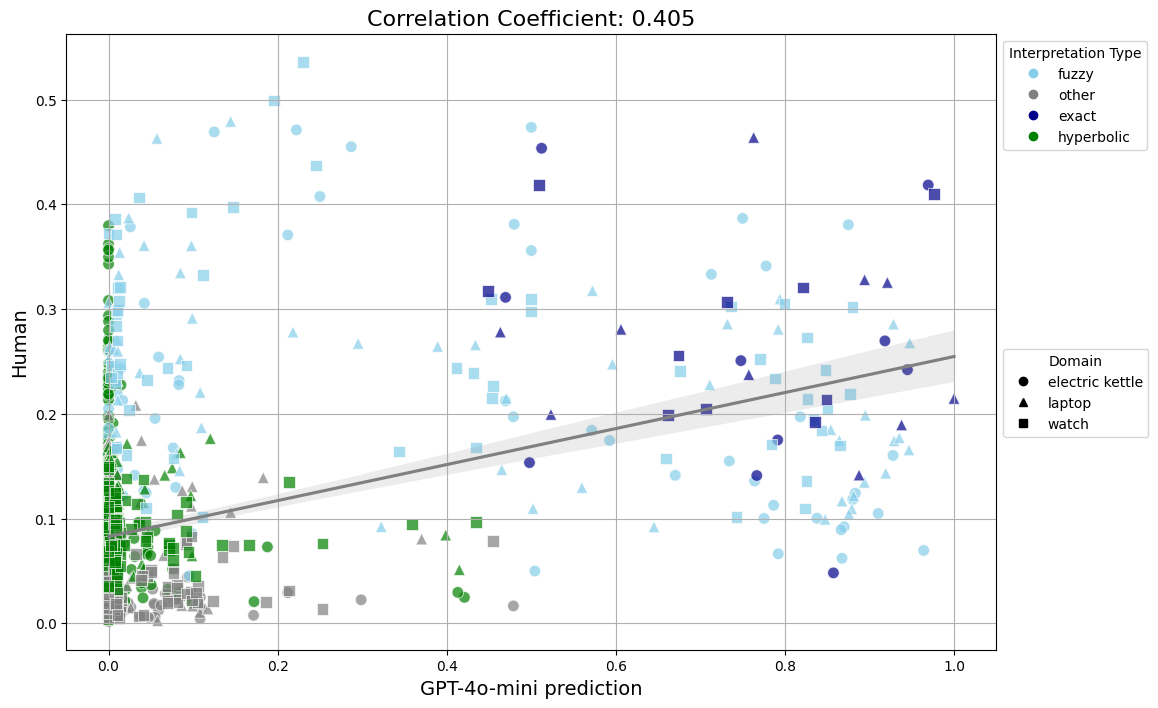

In [55]:
# replicate plot 2A
import matplotlib.lines as mlines
# Merge the datasets on (utterance, state) pairs
# merged_df = pd.merge(df_1b_v2, df_human, on=['domain', 'interpretationType', 'utterance', 'state'], suffixes=('_1b_v2', '_human'))

# Define a color palette with gradient colors, making 'Exact' the darkest
color_palette = {
    'exact': 'darkblue',
    'fuzzy': 'skyblue',
    'hyperbolic': 'green',
    'other': 'gray'
}

# Define markers for different domains
markers = {
    'electric kettle': 'o',  # Circle
    'laptop': '^',  # Triangle
    'watch': 's'  # Square
}

# Create the correlation plot
plt.figure(figsize=(12, 8))
plot = sns.scatterplot(data=df_1b_aligned_summary, x='probability', y='stateProb', 
                        style='item', hue='interpretationType',
                       palette=color_palette, markers=markers, s=70, alpha=0.7)

# Add a fitted line with a 95% confidence interval
sns.regplot(data=df_1b_aligned_summary, x='probability', y='stateProb', scatter=False, ci=95, color='gray')

# Set plot labels and title
plot.set_xlabel('GPT-4o-mini prediction', fontsize=14)
plot.set_ylabel('Human', fontsize=14)
# correlation coefficient
correlation_coefficient = df_1b_aligned_summary['probability'].corr(df_1b_aligned_summary['stateProb'])
plot.set_title(f'Correlation Coefficient: {round(correlation_coefficient, 3)}', fontsize=16)

# Add grid
plt.grid(True)

# Add a custom legend
legend_labels = df_1b_aligned_summary['interpretationType'].unique()
legend_handles = [mlines.Line2D([], [], color=color_palette[label], marker='o', linestyle='None', markersize=6, label=label) for label in legend_labels]
legend1 = plt.legend(handles=legend_handles, title='Interpretation Type', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.gca().add_artist(legend1)

domain_labels = df_1b_aligned_summary['item'].unique()
domain_handles = [mlines.Line2D([], [], color='black', marker=markers[label], linestyle='None', markersize=6, label=label) for label in domain_labels]
plt.legend(handles=domain_handles, title='Domain', bbox_to_anchor=(1.0, 0.5), loc='upper left')

# Show the plot
plt.show()

#### Figure 5B

In [11]:
def process_df(df, experiment_ratings):
    df["domain"] = ["electric kettle"]*100 + ["laptop"]*100 + ["watch"]*100
    df['numbers'] = df['scenarios'].str.findall(r'\d+')
    df['utterance'] = df['numbers'].str[0]
    df['state'] = df['numbers'].str[-1]
    df = df.drop(columns=['numbers'])
    df = df.drop(columns=['scenarios'])
    df["stateProb"] = experiment_ratings
    df['state'] = df['state'].astype(int)
    df['utterance'] = df['utterance'].astype(int)
    df['stateProb'] = df['stateProb'].astype(float)
    df['stateType'] = df.apply(lambda row: 'round' if row['state'] % 10 == 0 else 'sharp', axis=1)
    df['utteranceType'] = df.apply(lambda row: 'round' if row['utterance'] % 10 == 0 else 'sharp', axis=1)
    df.loc[df['stateType'] == 'sharp', 'state'] = df['state'].apply(lambda x: round(x, -1)) + 1
    df.loc[df['utteranceType'] == 'sharp', 'utterance'] = df['utterance'].apply(lambda x: round(x, -1)) + 1
    df = df.drop(columns=['stateType', 'utteranceType'])
    df = df.rename(columns={"domain": "item", "utterance": "utterance", "state": "prices", "stateProb": "rating"})
    return df

df_5b_v2 = process_df(pd.read_csv("../experiment_1b_v2.csv", header=None, names=["scenarios"]), experiment1b_ratings_v2)
df_5b_v3 = process_df(pd.read_csv("../experiment_1b_v3.csv", header=None, names=["scenarios"]), experiment1b_ratings_v3)

# save the dataframes to csv files
df_5b_v2.to_csv("df_5b_v2.csv", index=False)
df_5b_v3.to_csv("df_5b_v3.csv", index=False)

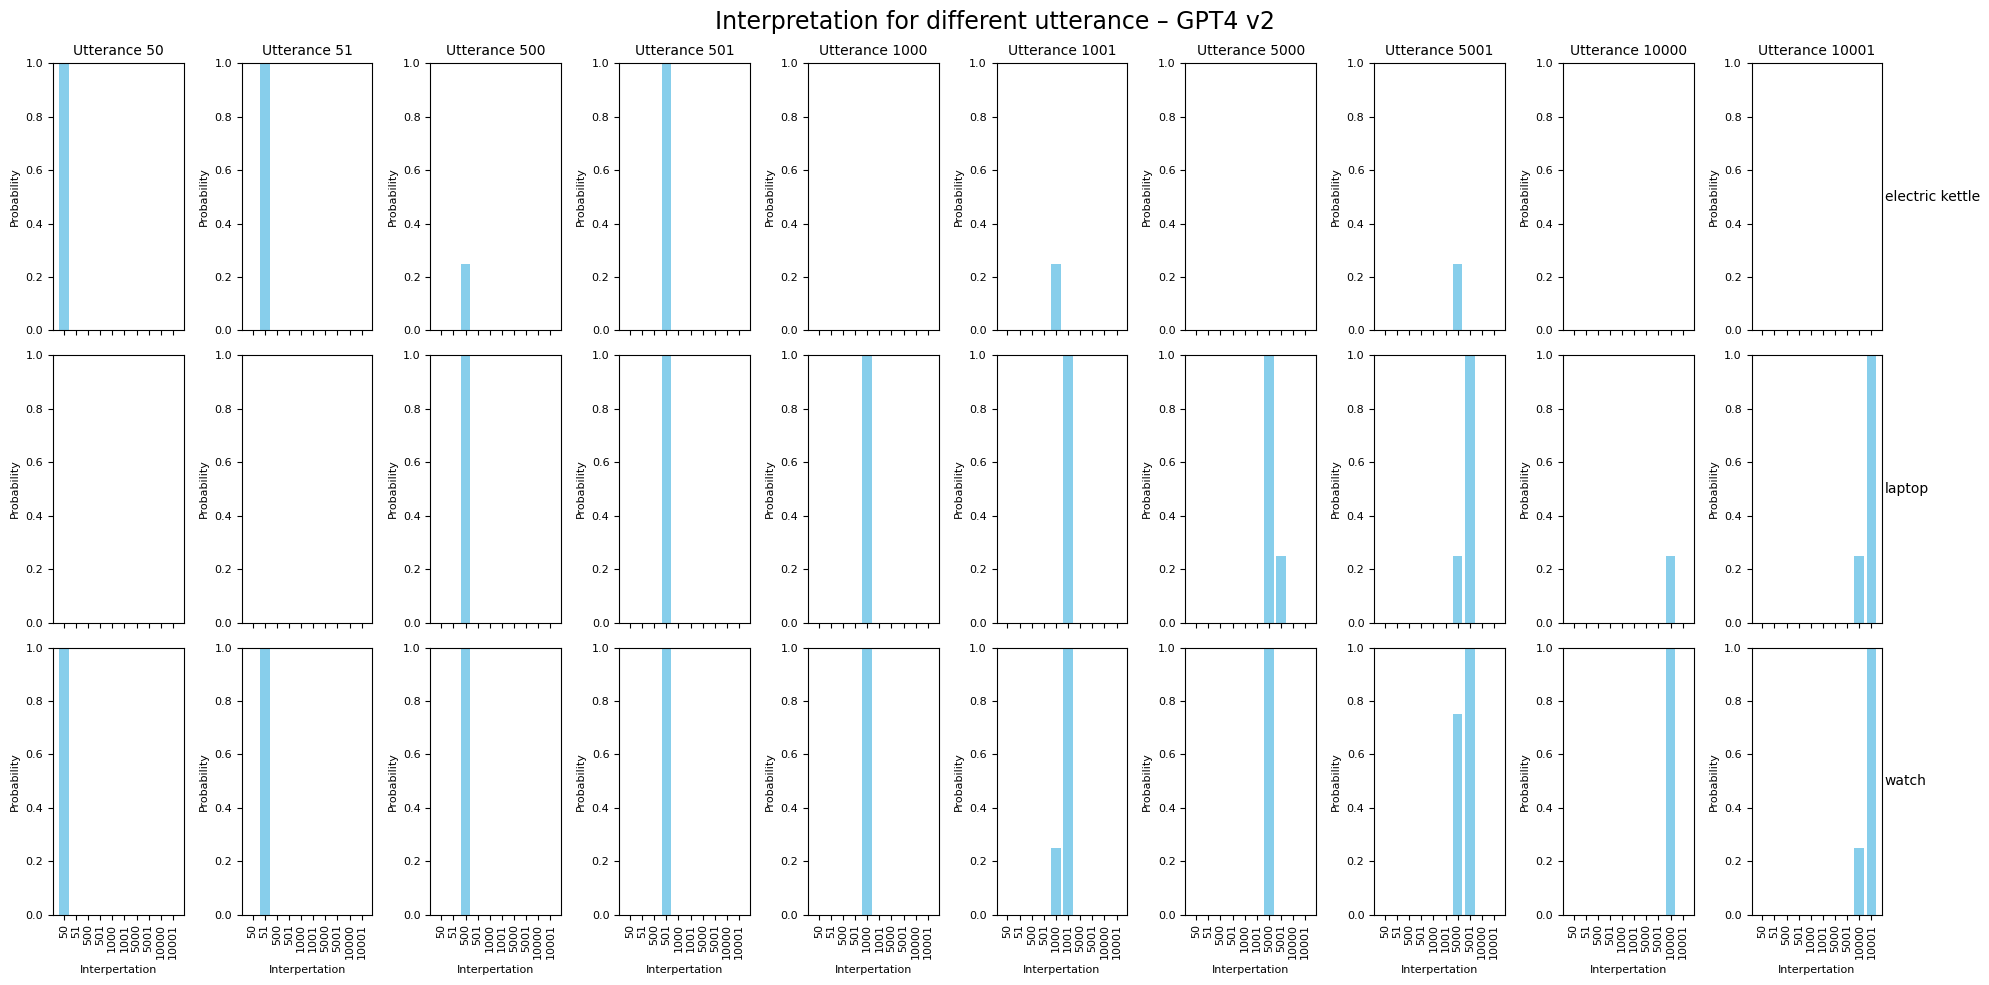

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# remove "workerID", "utteranceType", "utteranceExact", "utteranceRounded", "stateType", "stateRounded", "order"

df_experiment1a = pd.read_csv("df_5b_v2.csv")

# save the dataframe
# df_experiment1a_grouped.to_csv("../../../pragmatic_reasoning-main-2/data/results/df_experiment1_human_grouped.csv", index=False)

data = df_experiment1a

# Define the product categories
product_categories = ["electric kettle", "laptop", "watch"]

# Set the size of the plot
plt.figure(figsize=(20, 10))

# add the title
plt.suptitle("Interpretation for different utterance – GPT4 v2", fontsize=17)

# Consistent color for all the bars
bar_color = 'skyblue'

# Create subplots for each category and each utterance
for i, category in enumerate(product_categories, start=1):
    category_data = data[data['item'] == category]
    unique_utterances = category_data['utterance'].unique()
    
    for j, utterance in enumerate(unique_utterances, start=1):
        ax = plt.subplot(3, 10, (i-1)*10 + j)
        utterance_data = category_data[category_data['utterance'] == utterance]
        
        # Sort the data by price to have a consistent order in the plot
        utterance_data = utterance_data.sort_values(by='prices')
        
        # Create the bar plot
        plt.bar(utterance_data['prices'].astype(str), utterance_data['rating'], color=bar_color)
        
        # Set plot title and labels
        if i == 1:
            plt.title(f'Utterance {utterance}', fontsize=10)
        if i == 3:
            plt.xlabel('Interpertation', fontsize=8)
        else:
            ax.set_xticklabels([])
        plt.ylabel('Probability', fontsize=8)
        plt.xticks(rotation=90, fontsize=8)
        plt.yticks(fontsize=8)
        plt.ylim(0, 1.0)

        # Add notation on the right side
        if j == 10:
            plt.text(1.02, 0.5, category, va='center', ha='left', rotation=0, transform=ax.transAxes, fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()


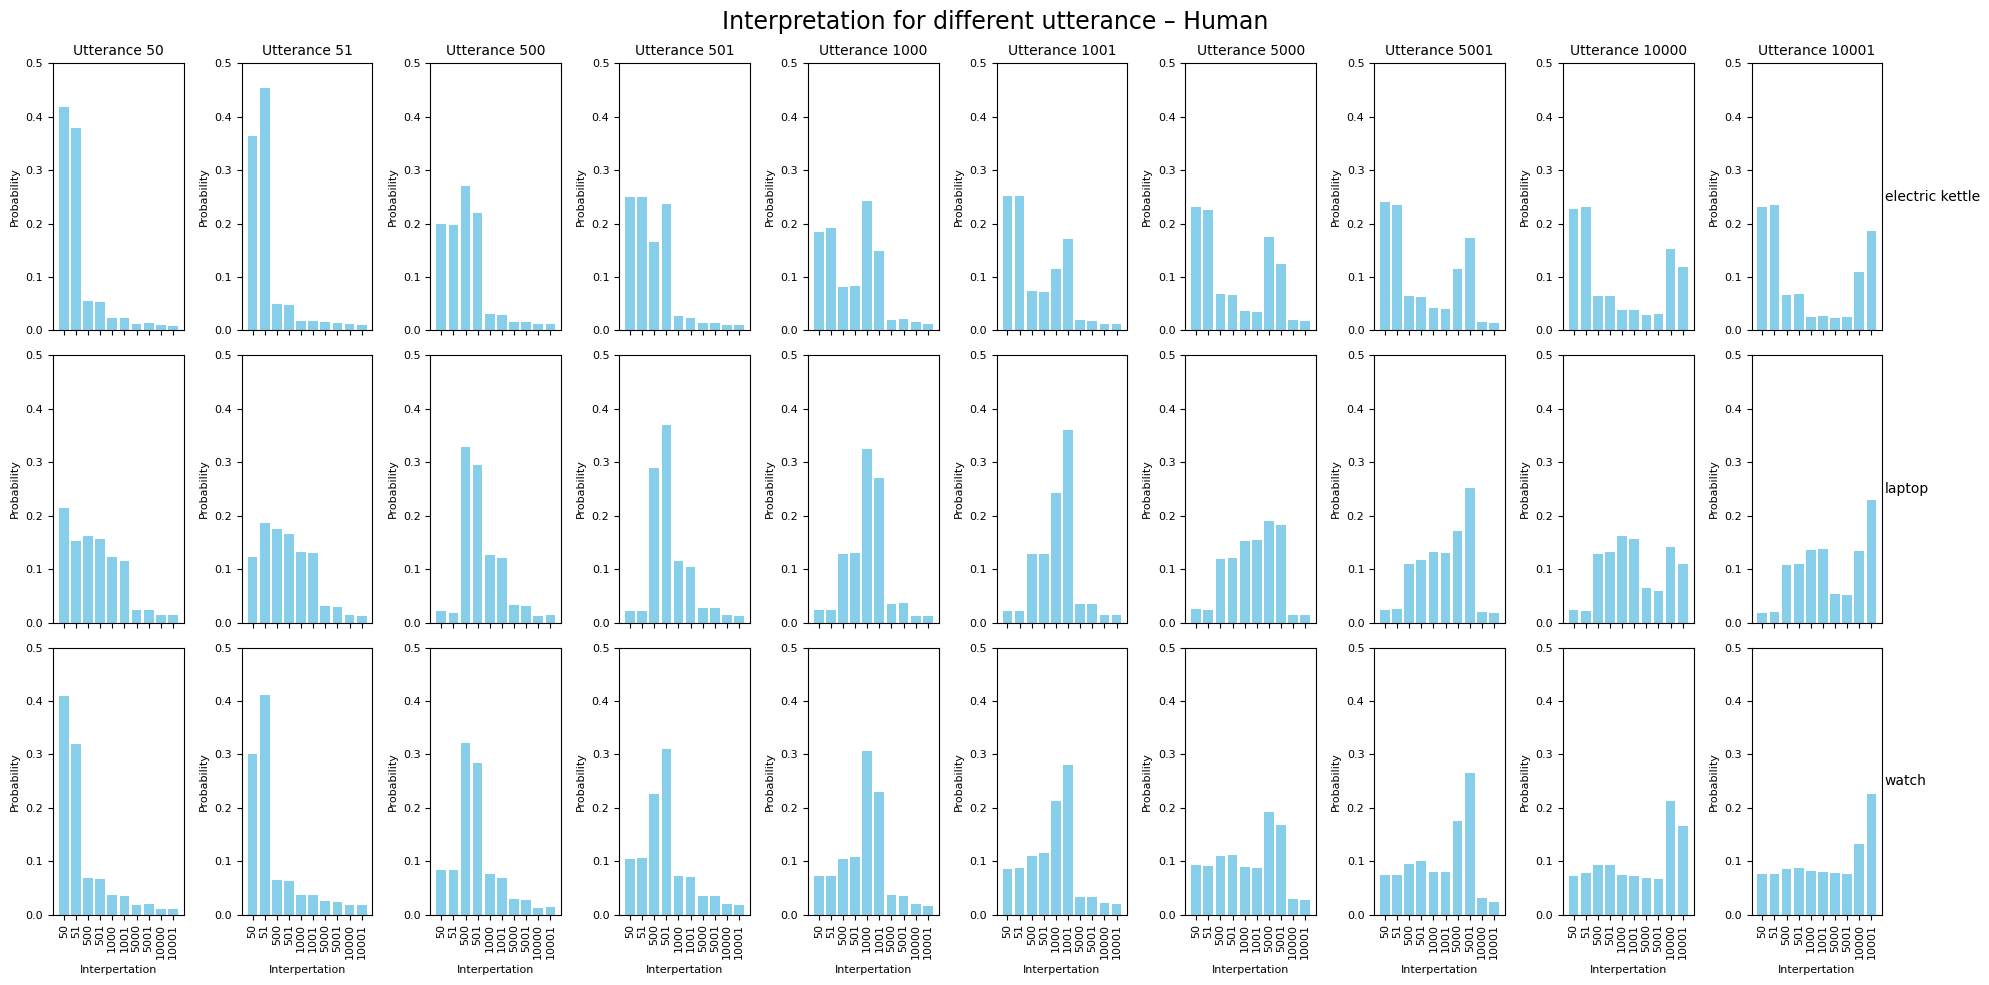

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# remove "workerID", "utteranceType", "utteranceExact", "utteranceRounded", "stateType", "stateRounded", "order"

df_experiment1a = pd.read_csv("experiment1-normalized.csv")
df_experiment1a = df_experiment1a.drop(columns=["workerID", "utteranceType", "utteranceExact", "utteranceRounded", "stateType", "stateRounded", "order", "affectProb"])
df_experiment1a

# group by domain first, then by utterance, and then by state and get the average of stateProb for each group
df_experiment1a_grouped = df_experiment1a.groupby(["domain", "utterance", "state"]).mean().reset_index()

# rename the columns to item, utterance, prices, rating
df_experiment1a_grouped = df_experiment1a_grouped.rename(columns={"domain": "item", "utterance": "utterance", "state": "prices", "stateProb": "rating"})

# save the dataframe
# df_experiment1a_grouped.to_csv("../../../pragmatic_reasoning-main-2/data/results/df_experiment1_human_grouped.csv", index=False)

data = df_experiment1a_grouped

# Define the product categories
product_categories = ["electric kettle", "laptop", "watch"]

# Set the size of the plot
plt.figure(figsize=(20, 10))

# add the title
plt.suptitle("Interpretation for different utterance – Human", fontsize=17)

# Consistent color for all the bars
bar_color = 'skyblue'

# Create subplots for each category and each utterance
for i, category in enumerate(product_categories, start=1):
    category_data = data[data['item'] == category]
    unique_utterances = category_data['utterance'].unique()
    
    for j, utterance in enumerate(unique_utterances, start=1):
        ax = plt.subplot(3, 10, (i-1)*10 + j)
        utterance_data = category_data[category_data['utterance'] == utterance]
        
        # Sort the data by price to have a consistent order in the plot
        utterance_data = utterance_data.sort_values(by='prices')
        
        # Create the bar plot
        plt.bar(utterance_data['prices'].astype(str), utterance_data['rating'], color=bar_color)
        
        # Set plot title and labels
        if i == 1:
            plt.title(f'Utterance {utterance}', fontsize=10)
        if i == 3:
            plt.xlabel('Interpertation', fontsize=8)
        else:
            ax.set_xticklabels([])
        plt.ylabel('Probability', fontsize=8)
        plt.xticks(rotation=90, fontsize=8)
        plt.yticks(fontsize=8)
        plt.ylim(0, 0.50)

        # Add notation on the right side
        if j == 10:
            plt.text(1.02, 0.5, category, va='center', ha='left', rotation=0, transform=ax.transAxes, fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()


#### Figure 4B

In [15]:
# add a column called domain with the first 100 rows as electric kettle, the second 100 rows as laptop, the third 100 rows as watch
df_4b_v2["domain"] = ["electric kettle"]*60 + ["laptop"]*60 + ["watch"]*60

# extract the two numbers from each line of the scenarios column and let the two to be in a list
df_4b_v2['numbers'] = df_4b_v2['scenarios'].str.findall(r'\d+')

# the first number in the numbers column should be in the new column called price, the second number should be in the new column called utterance
df_4b_v2['state'] = df_4b_v2['numbers'].str[0]
df_4b_v2['utterance'] = df_4b_v2['numbers'].str[1]

# drop the numbers column
df_4b_v2 = df_4b_v2.drop(columns=['numbers'])

# drop the column called scenarios
df_4b_v2 = df_4b_v2.drop(columns=['scenarios'])

# add experiment1b_ratings_v2 list to the dataframe as the rating
df_4b_v2["affectProb"] = experiment2_ratings_v2

# datatype of state and utterance should be int
df_4b_v2['state'] = df_4b_v2['state'].astype(int)
df_4b_v2['utterance'] = df_4b_v2['utterance'].astype(int)

# datatype of rating should be float
df_4b_v2['affectProb'] = df_4b_v2['affectProb'].astype(float)

# add a column called stateType, if state % 10 == 0, assign value "round", else assign value "sharp"
df_4b_v2['stateType'] = df_4b_v2.apply(lambda row: 'round' if row['state'] % 10 == 0 else 'sharp', axis=1)

# add a column called utteranceType, if utterance % 10 == 0, assign value "round", else assign value "sharp"
df_4b_v2['utteranceType'] = df_4b_v2.apply(lambda row: 'round' if row['utterance'] % 10 == 0 else 'sharp', axis=1)

# if stateType == "sharp", then reassign the state value to the closest round number and then plus 1
df_4b_v2.loc[df_4b_v2['stateType'] == 'sharp', 'state'] = df_4b_v2['state'].apply(lambda x: round(x, -1))

# if utteranceType == "sharp", then reassign the utterance value to the closest round number and then plus 1
df_4b_v2.loc[df_4b_v2['utteranceType'] == 'sharp', 'utterance'] = df_4b_v2['utterance'].apply(lambda x: round(x, -1))

# drop the stateType and utteranceType columns
df_4b_v2 = df_4b_v2.drop(columns=['stateType', 'utteranceType'])

# rename the columns to item, utterance, prices, rating
df_4b_v2 = df_4b_v2.rename(columns={"utterance": "utteranceRounded", "state": "stateRounded"})

NameError: name 'df_4b_v2' is not defined

In [ ]:
def process_df_4b(df, experiment_ratings):
    df["domain"] = ["electric kettle"]*60 + ["laptop"]*60 + ["watch"]*60
    df['numbers'] = df['scenarios'].str.findall(r'\d+')
    df['state'] = df['numbers'].str[0]
    df['utterance'] = df['numbers'].str[1]
    df = df.drop(columns=['numbers'])
    df = df.drop(columns=['scenarios'])
    df["affectProb"] = experiment_ratings
    df['state'] = df['state'].astype(int)
    df['utterance'] = df['utterance'].astype(int)
    df['affectProb'] = df['affectProb'].astype(float)
    df['stateType'] = df.apply(lambda row: 'round' if row['state'] % 10 == 0 else 'sharp', axis=1)
    df['utteranceType'] = df.apply(lambda row: 'round' if row['utterance'] % 10 == 0 else 'sharp', axis=1)
    df.loc[df['stateType'] == 'sharp', 'state'] = df['state'].apply(lambda x: round(x, -1))
    df.loc[df['utteranceType'] == 'sharp', 'utterance'] = df['utterance'].apply(lambda x: round(x, -1))
    df = df.drop(columns=['stateType', 'utteranceType'])
    df = df.rename(columns={"utterance": "utteranceRounded", "state": "stateRounded"})
    return df

In [ ]:
df_4b_v2 = process_df_4b(pd.read_csv("../experiment_2_v2.csv", header=None, names=["scenarios"]), experiment2_ratings_v2)
df_4b_v3 = process_df_4b(pd.read_csv("../experiment_2_v3.csv", header=None, names=["scenarios"]), experiment2_ratings_v3)

In [ ]:

df_4b_v2_literal = df_4b_v2[df_4b_v2["stateRounded"] == df_4b_v2["utteranceRounded"]]

df_4b_v2_literal_grouped = df_4b_v2_literal.groupby(["domain", "stateRounded"]).mean().reset_index()

df_4b_v2_literal_grouped.to_csv("df_4b_v2_literal_grouped.csv", index=False)

df_4b_v2_hyperbole = df_4b_v2[df_4b_v2["stateRounded"] < df_4b_v2["utteranceRounded"]]

df_4b_v2_hyperbole_grouped = df_4b_v2_hyperbole.groupby(["domain", "stateRounded"]).mean().reset_index()

df_4b_v2_hyperbole_grouped.to_csv("df_4b_v2_hyperbole_grouped.csv", index=False)

In [ ]:

df_4b_v3_literal = df_4b_v3[df_4b_v3["stateRounded"] == df_4b_v3["utteranceRounded"]]

df_4b_v3_literal_grouped = df_4b_v3_literal.groupby(["domain", "stateRounded"]).mean().reset_index()

df_4b_v3_literal_grouped.to_csv("df_4b_v3_literal_grouped.csv", index=False)

df_4b_v3_hyperbole = df_4b_v3[df_4b_v3["stateRounded"] < df_4b_v3["utteranceRounded"]]

df_4b_v3_hyperbole_grouped = df_4b_v3_hyperbole.groupby(["domain", "stateRounded"]).mean().reset_index()

df_4b_v3_hyperbole_grouped.to_csv("df_4b_v3_hyperbole_grouped.csv", index=False)

In [ ]:
df_2_human = pd.read_csv("experiment2-raw.csv")

# remove the columns "workerID", "utteranceExact", "utteranceType", "stateExact", "stateType", "order" in df_2_human
df_2_human = df_2_human.drop(["workerID", "utteranceExact", "utteranceType", "stateExact", "stateType", "order"], axis=1)
df_2_human

# show the lines that have stateRounded == utteranceRounded
df_2_human_literal = df_2_human[df_2_human["stateRounded"] == df_2_human["utteranceRounded"]]

# group by item and stateRounded for df_2_human_literal and then get the mean of the ratings for each group
df_2_human_literal_grouped = df_2_human_literal.groupby(["domain", "stateRounded"]).mean().reset_index()

# save to csv
df_2_human_literal_grouped.to_csv("df_2_human_literal_grouped.csv", index=False)

# show the items that have stateRounded < utteranceRounded
df_2_human_hyperbole = df_2_human[df_2_human["stateRounded"] < df_2_human["utteranceRounded"]]

# group by item and stateRounded for df_2_human_hyperbole and then get the mean of the ratings for each group
df_2_human_hyperbole_grouped = df_2_human_hyperbole.groupby(["domain", "stateRounded"]).mean().reset_index()

# save the dataframe
df_2_human_hyperbole_grouped.to_csv("df_2_human_hyperbole_grouped.csv", index=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from both datasets
file_path_grouped_1 = 'df_4b_v2_hyperbole_grouped.csv'
file_path_literal_1 = 'df_4b_v2_literal_grouped.csv'
data_grouped_1 = pd.read_csv(file_path_grouped_1)
data_literal_1 = pd.read_csv(file_path_literal_1)

file_path_grouped_2 = 'df_2_human_hyperbole_grouped.csv'
file_path_literal_2 = 'df_2_human_literal_grouped.csv'
data_grouped_2 = pd.read_csv(file_path_grouped_2)
data_literal_2 = pd.read_csv(file_path_literal_2)

file_path_grouped_3 = 'df_4b_v3_hyperbole_grouped.csv'
file_path_literal_3 = 'df_4b_v3_literal_grouped.csv'
data_grouped_3 = pd.read_csv(file_path_grouped_3)
data_literal_3 = pd.read_csv(file_path_literal_3)

# Specify the price states to include
price_states = [50, 500, 1000, 5000, 10000]

# Filter and prepare the grouped data
filtered_data_grouped_1 = data_grouped_1[data_grouped_1['stateRounded'].isin(price_states)]
filtered_data_grouped_1['stateRounded'] = filtered_data_grouped_1['stateRounded'].astype(str)
filtered_data_grouped_2 = data_grouped_2[data_grouped_2['stateRounded'].isin(price_states)]
filtered_data_grouped_2['stateRounded'] = filtered_data_grouped_2['stateRounded'].astype(str)
filtered_data_grouped_3 = data_grouped_3[data_grouped_3['stateRounded'].isin(price_states)]
filtered_data_grouped_3['stateRounded'] = filtered_data_grouped_3['stateRounded'].astype(str)

# Filter and prepare the literal data
filtered_data_literal_1 = data_literal_1[data_literal_1['stateRounded'].isin(price_states)]
filtered_data_literal_1['stateRounded'] = filtered_data_literal_1['stateRounded'].astype(str)
filtered_data_literal_2 = data_literal_2[data_literal_2['stateRounded'].isin(price_states)]
filtered_data_literal_2['stateRounded'] = filtered_data_literal_2['stateRounded'].astype(str)
filtered_data_literal_3 = data_literal_3[data_literal_3['stateRounded'].isin(price_states)]
filtered_data_literal_3['stateRounded'] = filtered_data_literal_3['stateRounded'].astype(str)

# Get the unique items for creating subplots
items_1 = filtered_data_grouped_1['domain'].unique()
domains_2 = filtered_data_grouped_2['domain'].unique()
items_3 = filtered_data_grouped_3['domain'].unique()

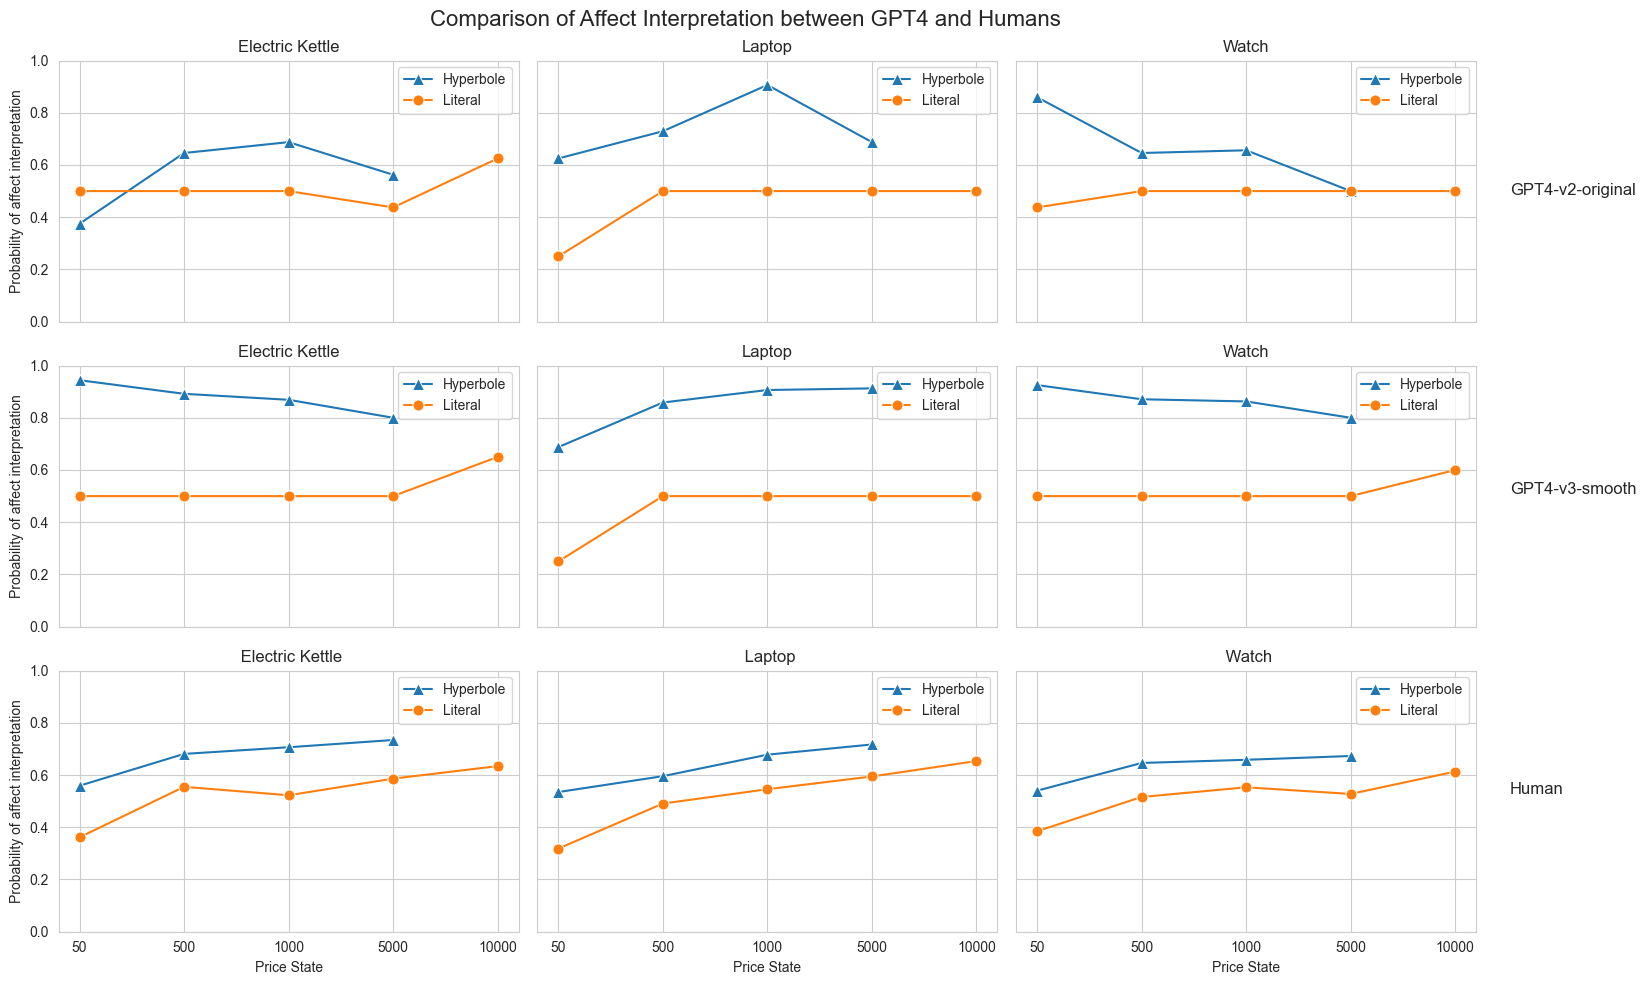

In [ ]:
# Set the style of the visualization
sns.set_style("whitegrid")

# Set marker size
marker_size = 8

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,10), sharex='col', sharey='row')

fig.suptitle('Comparison of Affect Interpretation between GPT4 and Humans', fontsize=16)

# Plot data from the first set of datasets
for ax, item in zip(axes[0], items_1):
    # Plot data from the hyperbole dataset
    item_data_grouped = filtered_data_grouped_1[filtered_data_grouped_1['domain'] == item]
    sns.lineplot(data=item_data_grouped, x='stateRounded', y='affectProb', marker='^', markersize=marker_size, ax=ax, label='Hyperbole')
    
    # Plot data from the literal dataset
    item_data_literal = filtered_data_literal_1[filtered_data_literal_1['domain'] == item]
    sns.lineplot(data=item_data_literal, x='stateRounded', y='affectProb', marker='o', markersize=marker_size, ax=ax, label='Literal')
    
    # Customize subplot
    ax.set_title(item.replace('_', ' ').title())
    ax.set_xlabel('Price State')
    ax.set_ylabel('Probability of affect interpretation')
    ax.legend()
    ax.set_ylim(0, 1.0)


# plot data from the third set of datasets
for ax, item in zip(axes[1], items_3):
    # Plot data from the hyperbole dataset
    item_data_grouped = filtered_data_grouped_3[filtered_data_grouped_3['domain'] == item]
    sns.lineplot(data=item_data_grouped, x='stateRounded', y='affectProb', marker='^', markersize=marker_size, ax=ax, label='Hyperbole')
    
    # Plot data from the literal dataset
    item_data_literal = filtered_data_literal_3[filtered_data_literal_3['domain'] == item]
    sns.lineplot(data=item_data_literal, x='stateRounded', y='affectProb', marker='o', markersize=marker_size, ax=ax, label='Literal')
    
    # Customize subplot
    ax.set_title(item.replace('_', ' ').title())
    ax.set_xlabel('Price State')
    ax.set_ylabel('Probability of affect interpretation')
    ax.legend()
    ax.set_ylim(0, 1.0)

# Plot data from the second set of datasets
for ax, domain in zip(axes[2], domains_2):
    # Plot data from the hyperbole dataset
    domain_data_grouped = filtered_data_grouped_2[filtered_data_grouped_2['domain'] == domain]
    sns.lineplot(data=domain_data_grouped, x='stateRounded', y='affectProb', marker='^', markersize=marker_size, ax=ax, label='Hyperbole')
    
    # Plot data from the literal dataset
    domain_data_literal = filtered_data_literal_2[filtered_data_literal_2['domain'] == domain]
    sns.lineplot(data=domain_data_literal, x='stateRounded', y='affectProb', marker='o', markersize=marker_size, ax=ax, label='Literal')
    
    # Customize subplot
    ax.set_title(domain.replace('_', ' ').title())
    ax.set_xlabel('Price State')
    ax.set_ylabel('Probability of affect interpretation')
    ax.legend()

    # set y limit
    ax.set_ylim(0, 1.0)

# Add "Human" text at the right side of the second row
fig.text(1.01, 0.2, 'Human', fontsize=12, verticalalignment='center')

# Add "LM" text at the right side of the third row
fig.text(1.01, 0.5, 'GPT4-v3-smooth', fontsize=12, verticalalignment='center')

# Add "LM" text at the right side of the first row
fig.text(1.01, 0.8, 'GPT4-v2-original', fontsize=12, verticalalignment='center')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# save the figure
# fig.savefig("./0_shot_cot_plot_data/plots/figure_4b.png")

#### Figure 4a: human and LM

In [ ]:
# group df_2_human_hyperbole first by domain and stateRound, then group by utteranceRound and get the mean of the affectProb
df_2_human_hyperbole_grouped = df_2_human_hyperbole.groupby(["domain", "stateRounded", "utteranceRounded"]).mean().reset_index()

# save the dataframe
df_2_human_hyperbole_grouped.to_csv("df_2_human_hyperbole_grouped_4a.csv", index=False)

# concatenate df_2_human_hyperbole_grouped_4a and df_2_human_literal_grouped
df_2_human_hyperbole_grouped_4a = pd.read_csv("df_2_human_hyperbole_grouped_4a.csv")

df_human_4a = pd.concat([df_2_human_hyperbole_grouped_4a, df_2_human_literal_grouped])

# rearragne df_human_4a by domain and then by staterounded and utterancerounded
df_human_4a = df_human_4a.sort_values(by=["domain", "stateRounded", "utteranceRounded"]).reset_index(drop=True)
df_human_4a["utteranceRounded"] = df_human_4a["utteranceRounded"].astype(int)

# rename the columns of df_human_4a to the same as the df_4b

df_human_4a = df_human_4a.rename(columns={"domain":"item", "stateRounded":"price_state", "utteranceRounded":"utterance", "affectProb":"rating"})

# save the dataframe
df_human_4a.to_csv("df_human_4a.csv", index=False)


In [ ]:
df_4b_v2_hyperbole_grouped = df_4b_v2_hyperbole.groupby(["domain", "stateRounded", "utteranceRounded"]).mean().reset_index()

df_4b_v2_hyperbole_grouped.to_csv("df_4b_v2_hyperbole_grouped_4a.csv", index=False)

df_4b_v2_hyperbole_grouped_4a = pd.read_csv("df_4b_v2_hyperbole_grouped_4a.csv")

df_4b_v2_4a = pd.concat([df_4b_v2_hyperbole_grouped_4a, df_4b_v2_literal_grouped])

df_4b_v2_4a = df_4b_v2_4a.sort_values(by=["domain", "stateRounded", "utteranceRounded"]).reset_index(drop=True)
df_4b_v2_4a["utteranceRounded"] = df_4b_v2_4a["utteranceRounded"].astype(int)

df_4b_v2_4a = df_4b_v2_4a.rename(columns={"domain":"item", "stateRounded":"price_state", "utteranceRounded":"utterance", "affectProb":"rating"})

df_4b_v2_4a.to_csv("df_4b_v2_4a.csv", index=False)




df_4b_v3_hyperbole_grouped = df_4b_v3_hyperbole.groupby(["domain", "stateRounded", "utteranceRounded"]).mean().reset_index()

df_4b_v3_hyperbole_grouped.to_csv("df_4b_v3_hyperbole_grouped_4a.csv", index=False)

df_4b_v3_hyperbole_grouped_4a = pd.read_csv("df_4b_v3_hyperbole_grouped_4a.csv")

df_4b_v3_4a = pd.concat([df_4b_v3_hyperbole_grouped_4a, df_4b_v3_literal_grouped])

df_4b_v3_4a = df_4b_v3_4a.sort_values(by=["domain", "stateRounded", "utteranceRounded"]).reset_index(drop=True)
df_4b_v3_4a["utteranceRounded"] = df_4b_v3_4a["utteranceRounded"].astype(int)

df_4b_v3_4a = df_4b_v3_4a.rename(columns={"domain":"item", "stateRounded":"price_state", "utteranceRounded":"utterance", "affectProb":"rating"})

df_4b_v3_4a.to_csv("df_4b_v3_4a.csv", index=False)

0.37542234135043345


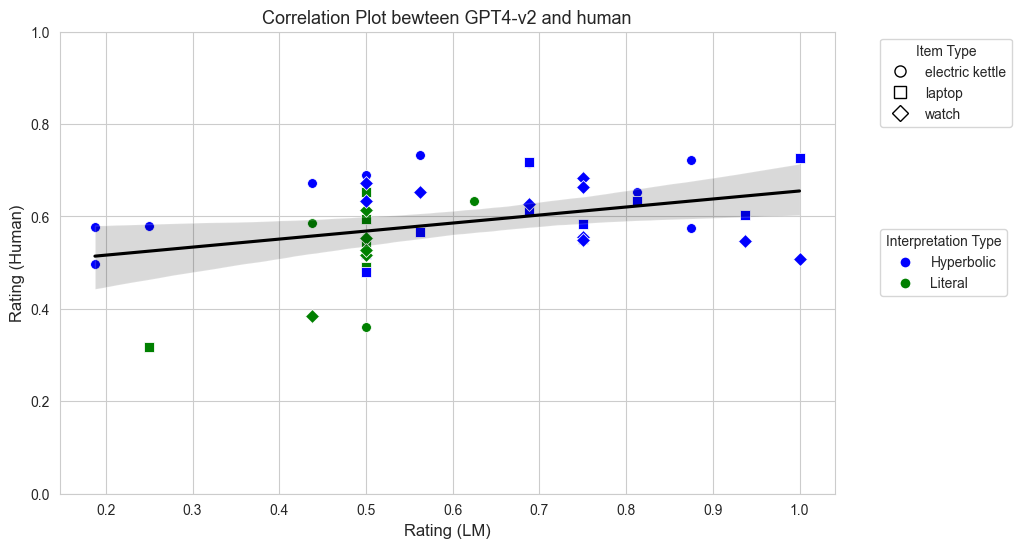

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df_4b = pd.read_csv('df_4b_v2_4a.csv')
df_human_4a = pd.read_csv('df_human_4a.csv')

# Standardize the 'item' column in both dataframes for a successful merge
df_4b['item'] = df_4b['item'].str.replace('_', ' ')
df_human_4a['item'] = df_human_4a['item'].str.strip()

# Merge the dataframes based on 'item', 'price_state', and 'utterance'
merged_df = pd.merge(df_4b, df_human_4a, on=['item', 'price_state', 'utterance'], suffixes=('_4b', '_human_4a'))

# Define marker styles for different items
marker_styles = {'electric kettle': 'o', 'laptop': 's', 'watch': 'D'}

# Create the scatter plot with specified conditions and solid markers
plt.figure(figsize=(10, 6))

# Marker size
marker_size = 50

# Adding scatter plots for each item and condition
for item, marker in marker_styles.items():
    subset = merged_df[merged_df['item'] == item]
    
    # Points where price_state == utterance (literal)
    subset_equal = subset[subset['price_state'] == subset['utterance']]
    sns.scatterplot(data=subset_equal, x='rating_4b', y='rating_human_4a', marker=marker, s=marker_size, color='green', label=f'{item}')
    
    # Points where price_state < utterance (hyperbolic)
    subset_less = subset[subset['price_state'] < subset['utterance']]
    sns.scatterplot(data=subset_less, x='rating_4b', y='rating_human_4a', marker=marker, s=marker_size, color='blue')

# Add the fitted regression line with 95% confidence interval
sns.regplot(data=merged_df, x='rating_4b', y='rating_human_4a', scatter=False, ci=95, color='black')

# print out the correlation coefficient
print(merged_df['rating_4b'].corr(merged_df['rating_human_4a']))

# Setting plot title and labels
plt.title('Correlation Plot bewteen GPT4-v2 and human', fontsize=13)
plt.xlabel('Rating (LM)', fontsize=12)
plt.ylabel('Rating (Human)', fontsize=12)

# set y limit
plt.ylim(0, 1.0)

# Creating custom legends
legend_labels_items = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=8, markeredgecolor='black', label='electric kettle'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='none', markersize=8, markeredgecolor='black', label='laptop'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='none', markersize=8, markeredgecolor='black', label='watch')
]
legend_labels_interpretation = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Hyperbolic'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Literal')
]

legend1 = plt.legend(handles=legend_labels_items, title='Item Type', bbox_to_anchor=(1.05, 1), loc='upper left')
legend2 = plt.legend(handles=legend_labels_interpretation, title='Interpretation Type', bbox_to_anchor=(1.05, 0.5), loc='center left')

# Add legends back
plt.gca().add_artist(legend1)

# Show the plot
plt.show()

# save the figure
# plt.savefig("./0_shot_cot_plot_data/plots/figure_4a.png")

#### Figure 3a

In [ ]:
#computed the probability of a participant interpreting an utterance u as hyperbolic by summing up ratings for each interpreted price state s where u > s

In [ ]:
df_experiment1a = pd.read_csv("experiment1-normalized.csv")
df_experiment1a = df_experiment1a.drop(columns=["workerID", "utteranceType", "utteranceExact", "utteranceRounded", "stateType", "stateRounded", "order", "affectProb"])

# show the lines that have state < utterance and reindex the dataframe
df_experiment1a_hyperbole = df_experiment1a[df_experiment1a["state"] < df_experiment1a["utterance"]].reset_index(drop=True)

# rename the columns to item, utterance, prices, rating
df_experiment1a_hyperbole = df_experiment1a_hyperbole.rename(columns={"domain": "item", "utterance": "utterance", "state": "prices", "stateProb": "rating"})

# let the second columns show prices and the third show utterance
df_experiment1a_hyperbole = df_experiment1a_hyperbole[["item", "prices", "utterance", "rating"]]

# only keep the rows where uttearnce % 10 == 0
df_experiment1a_hyperbole = df_experiment1a_hyperbole[df_experiment1a_hyperbole["utterance"] % 10 == 0]

#  group by item and then by utterance and then sum up the ratings for all prices
df_experiment1a_hyperbole_grouped = df_experiment1a_hyperbole.groupby(["item", "utterance"]).sum().reset_index()

In [ ]:
df_experiment1a_hyperbole_grouped

,item,utterance,prices,rating
0,electric kettle,500,7070,27.766810
1,electric kettle,1000,66120,32.369390
2,electric kettle,5000,189283,40.415878
3,electric kettle,10000,812448,45.157150
4,laptop,500,6060,2.383234
5,laptop,1000,73834,20.486105
6,laptop,5000,170665,32.904290
7,laptop,10000,917280,52.435476
8,watch,500,6464,10.719236
9,watch,1000,63916,20.693830


In [ ]:

# normalize the rating by item
df_experiment1a_hyperbole_grouped["rating"] = df_experiment1a_hyperbole_grouped.groupby("item")["rating"].transform(lambda x: x*2/x.sum())

df_experiment1a_hyperbole_grouped

# save the dataframe
df_experiment1a_hyperbole_grouped.to_csv("df_experiment1a_human_hyperbole_grouped.csv", index=False)

In [ ]:
df_3a

,item,utterance,prices,rating
0,electric kettle,50,50,1.0
1,electric kettle,50,51,0.0
2,electric kettle,50,500,0.0
3,electric kettle,50,501,0.0
4,electric kettle,50,1000,0.0
...,...,...,...,...
295,watch,10001,1001,0.0
296,watch,10001,5000,0.0
297,watch,10001,5001,0.0
298,watch,10001,10000,0.0


In [ ]:
df_3a = pd.read_csv("df_5b_v2.csv")

# show the lines that have state < utterance and reindex the dataframe
df_3a_hyperbole = df_3a[df_3a["prices"] < df_3a["utterance"]].reset_index(drop=True)

# only keep the rows where uttearnce % 10 == 0
df_3a_hyperbole = df_3a_hyperbole[df_3a_hyperbole["utterance"] % 10 == 0]

#  group by item and then by utterance and then sum up the ratings for all prices
df_3a_hyperbole_grouped = df_3a_hyperbole.groupby(["item", "utterance"]).sum().reset_index()

# normalize the rating by item else rating is 0
df_3a_hyperbole_grouped["rating"] = df_3a_hyperbole_grouped.groupby("item")["rating"].transform(lambda x: x/x.sum())

# convert all the NaN in the rating column to 0
df_3a_hyperbole_grouped["rating"] = df_3a_hyperbole_grouped["rating"].fillna(0)

# save the dataframe
df_3a_hyperbole_grouped.to_csv("df_3a_hyperbole_grouped_v2.csv", index=False)

,item,utterance,prices,rating
0,electric kettle,500,101,0.0
1,electric kettle,1000,1102,0.0
2,electric kettle,5000,3103,0.0
3,electric kettle,10000,13104,0.0
4,laptop,500,101,0.0
5,laptop,1000,1102,0.0
6,laptop,5000,3103,0.0
7,laptop,10000,13104,0.0
8,watch,500,101,0.0
9,watch,1000,1102,0.0


In [ ]:
df_3a = pd.read_csv("df_5b_v3.csv")

# show the lines that have state < utterance and reindex the dataframe
df_3a_hyperbole = df_3a[df_3a["prices"] < df_3a["utterance"]].reset_index(drop=True)

# only keep the rows where uttearnce % 10 == 0
df_3a_hyperbole = df_3a_hyperbole[df_3a_hyperbole["utterance"] % 10 == 0]

#  group by item and then by utterance and then sum up the ratings for all prices
df_3a_hyperbole_grouped = df_3a_hyperbole.groupby(["item", "utterance"]).sum().reset_index()

# normalize the rating by item else rating is 0
df_3a_hyperbole_grouped["rating"] = df_3a_hyperbole_grouped.groupby("item")["rating"].transform(lambda x: x/x.sum())

# convert all the NaN in the rating column to 0
df_3a_hyperbole_grouped["rating"] = df_3a_hyperbole_grouped["rating"].fillna(0)

# save the dataframe
df_3a_hyperbole_grouped.to_csv("df_3a_hyperbole_grouped_v3.csv", index=False)

,item,utterance,prices,rating
0,electric kettle,500,101,0.0
1,electric kettle,1000,1102,0.0
2,electric kettle,5000,3103,0.5
3,electric kettle,10000,13104,0.5
4,laptop,500,101,0.0
5,laptop,1000,1102,0.0
6,laptop,5000,3103,0.0
7,laptop,10000,13104,0.0
8,watch,500,101,0.0
9,watch,1000,1102,0.0


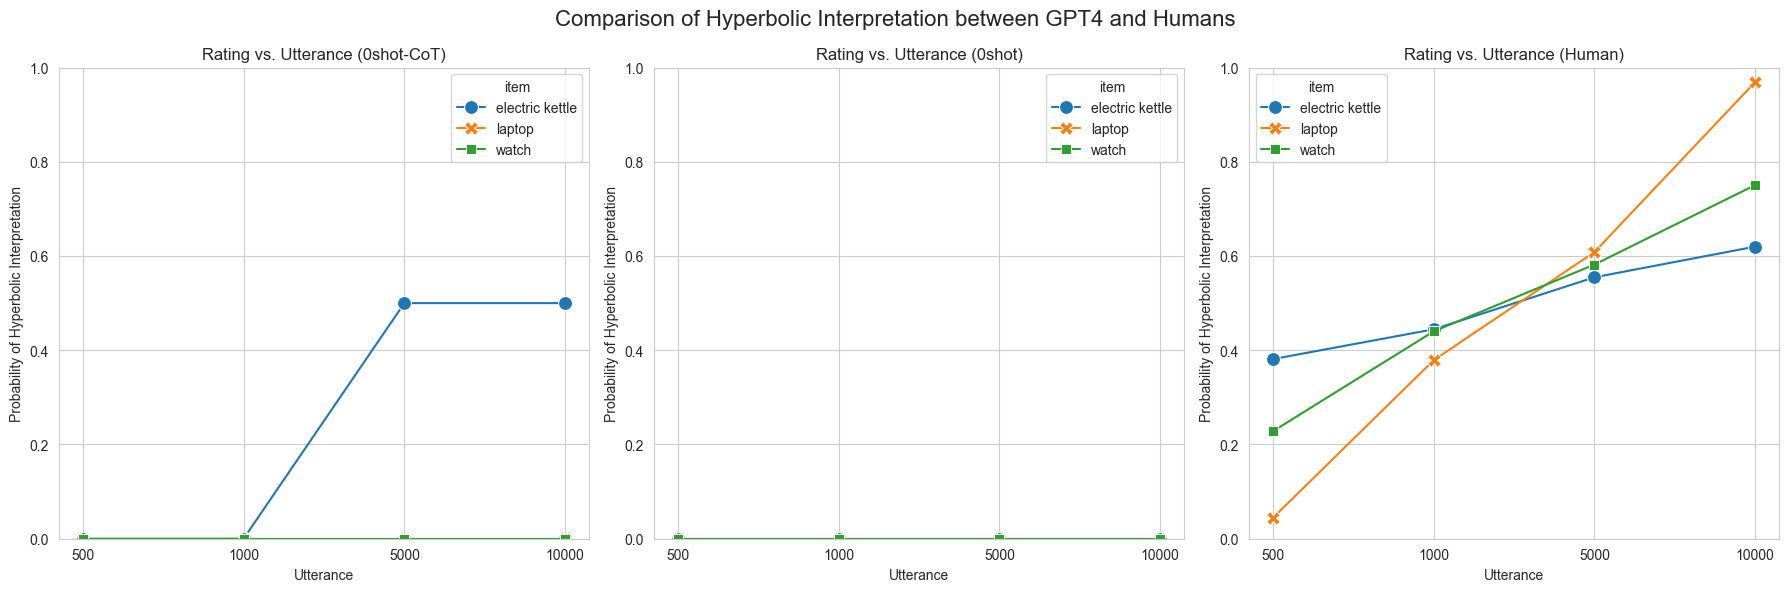

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Add a title to the figure
fig.suptitle('Comparison of Hyperbolic Interpretation between GPT4 and Humans', fontsize=16)

# File paths for the three datasets
file_paths = [
    'df_3a_hyperbole_grouped_0shot_cot.csv',
    'df_3a_hyperbole_grouped_0shot.csv',
    'df_experiment1a_human_hyperbole_grouped.csv'
]

# Titles for the subplots
titles = [
    'Rating vs. Utterance (0shot-CoT)',
    'Rating vs. Utterance (0shot)',
    'Rating vs. Utterance (Human)'
]

for i, (file_path, title) in enumerate(zip(file_paths, titles)):
    # Load the data from the CSV file
    data = pd.read_csv(file_path)

    # Filter the data to include only the specified utterance values
    filtered_data = data[data['utterance'].isin([500, 1000, 5000, 10000])]

    # Convert 'utterance' to string
    filtered_data['utterance'] = filtered_data['utterance'].astype(str)

    # Create the categorical line plot
    sns.lineplot(ax=axs[i], data=filtered_data, x='utterance', y='rating', hue='item', style='item', markers=True, markersize=10, dashes=False)

    # Set plot labels and title
    axs[i].set_xlabel('Utterance')
    axs[i].set_ylabel('Probability of Hyperbolic Interpretation')
    axs[i].set_ylim(0, 1.0)
    axs[i].set_title(title)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


### data experiment_3a: 3 bar plots (price prior)

In [ ]:
# electric_kettle, laptop, watch should be in the column named "item" and another column should be called "rating"
# all three should be in the same dataframe
import pandas as pd

prices = [50, 51, 500, 501, 1000, 1001, 5000, 5001, 10000, 10001]

electric_kettle_df = pd.DataFrame({"item": ["electric kettle"]*10, "prices": prices, "rating": experiment3a_ratings_v2[0:10]})
laptop_df = pd.DataFrame({"item": ["laptop"]*10, "prices": prices, "rating": experiment3a_ratings_v2[10:20]})
watch_df = pd.DataFrame({"item": ["watch"]*10, "prices": prices,  "rating": experiment3a_ratings_v2[20:30]})

experiment_3a = pd.concat([electric_kettle_df, laptop_df, watch_df])

experiment_3a

# save the dataframe
experiment_3a.to_csv("experiment_3a_v2.csv", index=False)

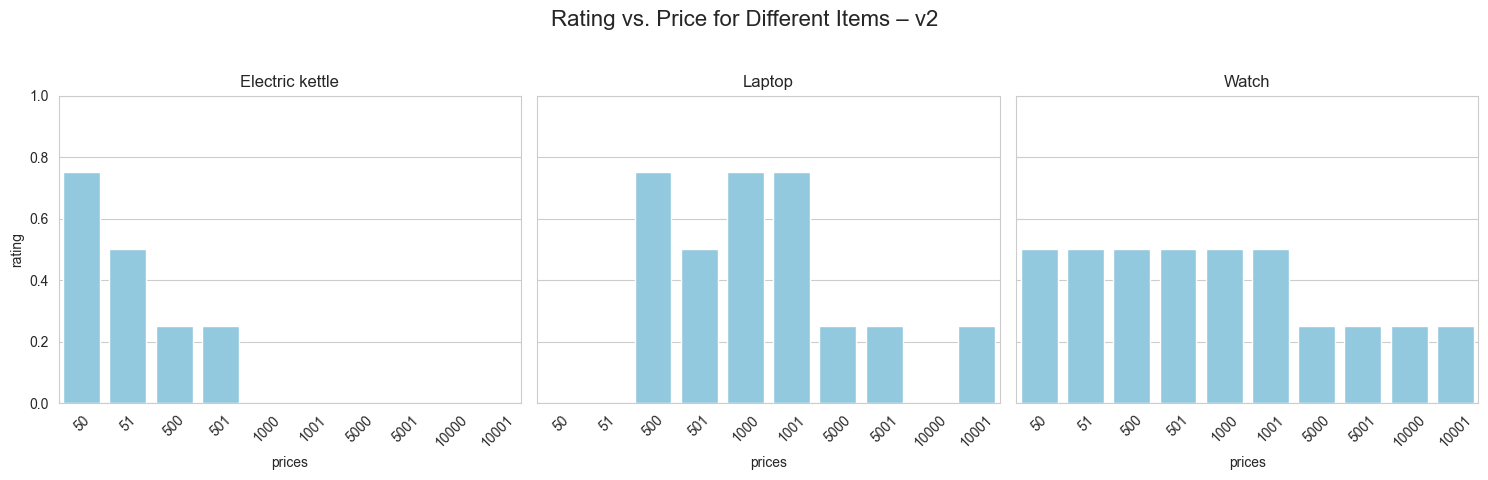

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the CSV file
file_path = 'experiment_3a_v2.csv'
data = pd.read_csv(file_path)

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Set a title for the entire plot
fig.suptitle('Rating vs. Price for Different Items – v2', fontsize=16)

# List of items
items = ['electric kettle', 'laptop', 'watch']

# Common color for the bars
bar_color = 'skyblue'

# Loop through the items and create a bar plot for each
for i, item in enumerate(items):
    # Filter the data for the current item
    item_data = data[data['item'] == item]
    
    # Create a bar plot with the same color for all bars
    sns.barplot(x='prices', y='rating', data=item_data, ax=axes[i], color=bar_color)
    
    # Set the title for each subplot
    axes[i].set_title(item.replace('_', ' ').capitalize())
    
    # Rotate the x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=45)

    # set y limit
    axes[i].set_ylim(0, 1.0)

# Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()


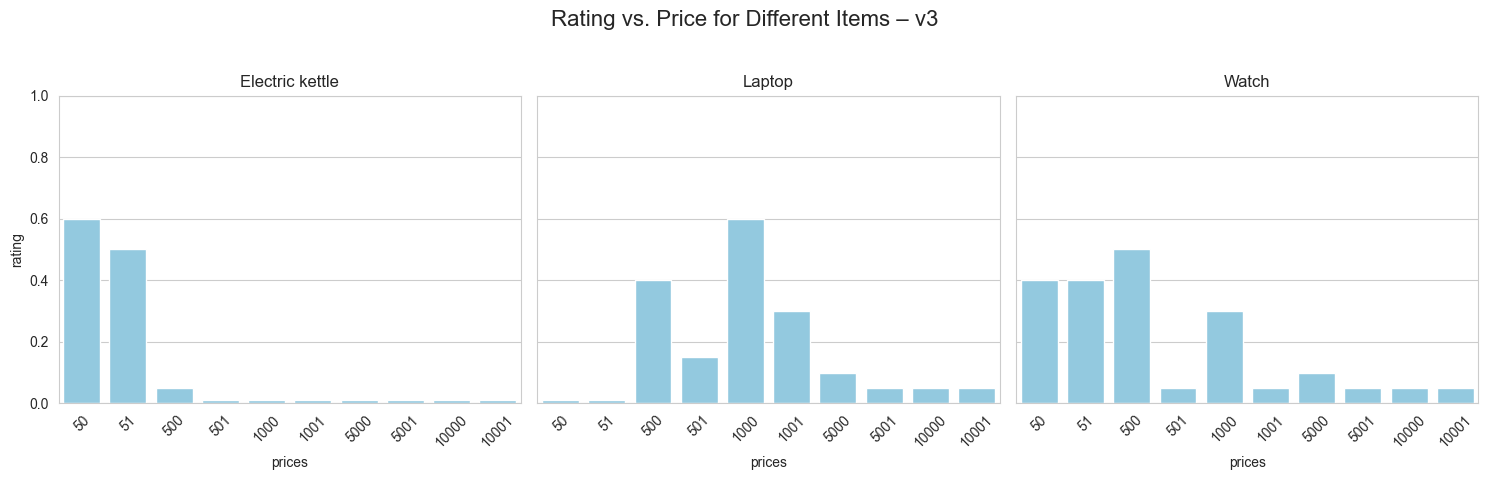

In [ ]:
# electric_kettle, laptop, watch should be in the column named "item" and another column should be called "rating"
# all three should be in the same dataframe
import pandas as pd

prices = [50, 51, 500, 501, 1000, 1001, 5000, 5001, 10000, 10001]

electric_kettle_df = pd.DataFrame({"item": ["electric kettle"]*10, "prices": prices, "rating": experiment3a_ratings_v3[0:10]})
laptop_df = pd.DataFrame({"item": ["laptop"]*10, "prices": prices, "rating": experiment3a_ratings_v3[10:20]})
watch_df = pd.DataFrame({"item": ["watch"]*10, "prices": prices,  "rating": experiment3a_ratings_v3[20:30]})

experiment_3a = pd.concat([electric_kettle_df, laptop_df, watch_df])

# save the dataframe
experiment_3a.to_csv("experiment_3a_v3.csv", index=False)

# Load the data from the CSV file
file_path = 'experiment_3a_v3.csv'
data = pd.read_csv(file_path)

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Set a title for the entire plot
fig.suptitle('Rating vs. Price for Different Items – v3', fontsize=16)

# List of items
items = ['electric kettle', 'laptop', 'watch']

# Common color for the bars
bar_color = 'skyblue'

# Loop through the items and create a bar plot for each
for i, item in enumerate(items):
    # Filter the data for the current item
    item_data = data[data['item'] == item]
    
    # Create a bar plot with the same color for all bars
    sns.barplot(x='prices', y='rating', data=item_data, ax=axes[i], color=bar_color)
    
    # Set the title for each subplot
    axes[i].set_title(item.replace('_', ' ').capitalize())
    
    # Rotate the x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=45)

    # set y limit
    axes[i].set_ylim(0, 1.0)

# Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()


### data experiment_3b: 3 bar plots and three line plots

In [ ]:
# electric_kettle, laptop, watch should be in the column named "item" and another column should be called "rating"
# all three should be in the same dataframe
import pandas as pd

prices = [50, 51, 500, 501, 1000, 1001, 5000, 5001, 10000, 10001]

electric_kettle_df = pd.DataFrame({"item": ["electric kettle"]*10, "prices": prices, "rating": experiment3b_ratings_v2[0:10]})
laptop_df = pd.DataFrame({"item": ["laptop"]*10, "prices": prices, "rating": experiment3b_ratings_v2[10:20]})
watch_df = pd.DataFrame({"item": ["watch"]*10, "prices": prices,  "rating": experiment3b_ratings_v2[20:30]})

experiment_3b = pd.concat([electric_kettle_df, laptop_df, watch_df])

# save the dataframe
experiment_3b.to_csv("experiment_3b_v2.csv", index=False)

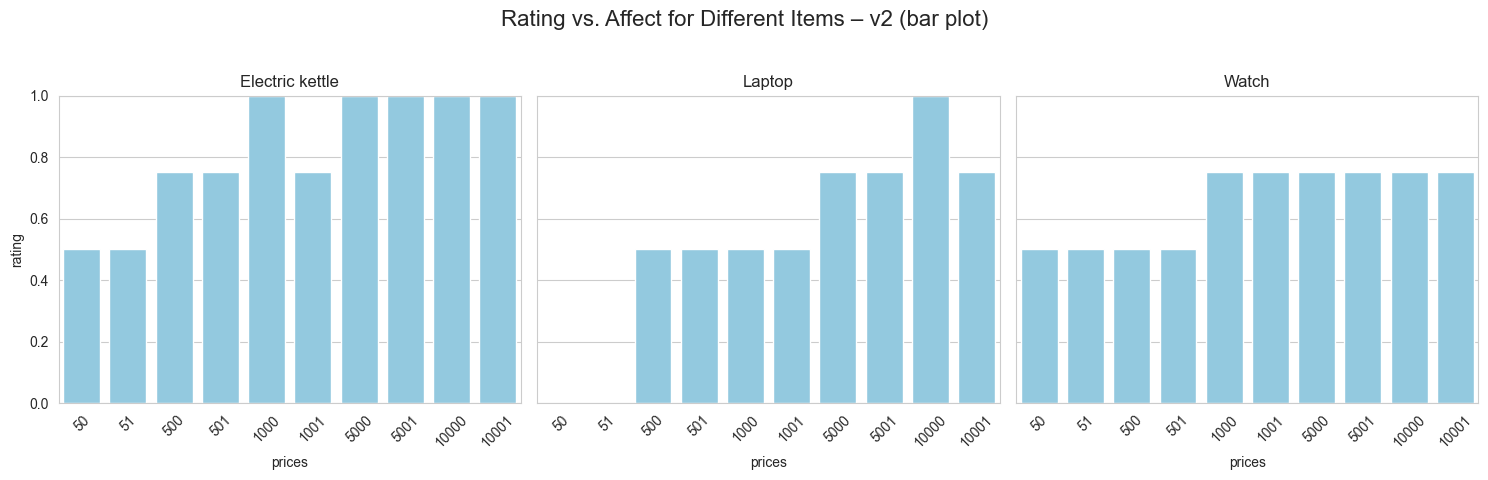

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the CSV file
file_path = 'experiment_3b_v2.csv'
data = pd.read_csv(file_path)

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Set a title for the entire plot
fig.suptitle('Rating vs. Affect for Different Items – v2 (bar plot)', fontsize=16)

# List of items
items = ['electric kettle', 'laptop', 'watch']

# Common color for the bars
bar_color = 'skyblue'

# Loop through the items and create a bar plot for each
for i, item in enumerate(items):
    # Filter the data for the current item
    item_data = data[data['item'] == item]
    
    # Create a bar plot with the same color for all bars
    sns.barplot(x='prices', y='rating', data=item_data, ax=axes[i], color=bar_color)
    
    # Set the title for each subplot
    axes[i].set_title(item.replace('_', ' ').capitalize())
    
    # Rotate the x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=45)

    # set y limit
    axes[i].set_ylim(0, 1.0)

# Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()


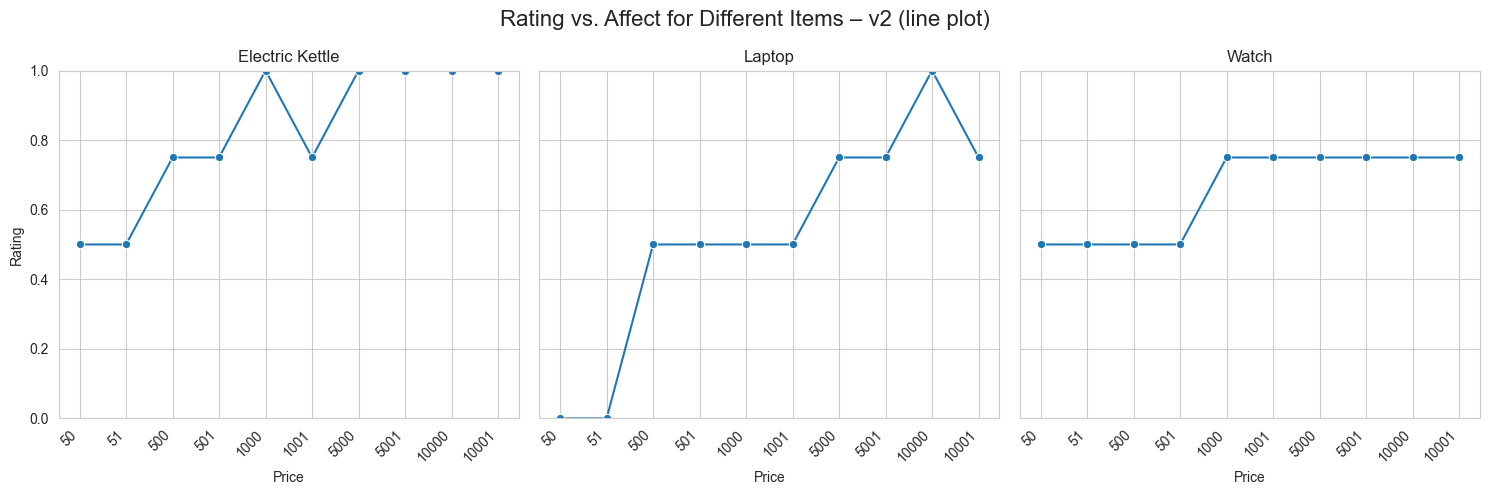

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = 'experiment_3b_v2.csv'
data = pd.read_csv(file_path)

# Convert prices to strings
data['prices'] = data['prices'].astype(str)

# Filter the data for each item
electric_kettle_data = data[data['item'] == 'electric kettle']
laptop_data = data[data['item'] == 'laptop']
watch_data = data[data['item'] == 'watch']

# Select the first 10 unique prices for each item
unique_prices_electric_kettle = electric_kettle_data['prices'].unique()[:10]
unique_prices_laptop = laptop_data['prices'].unique()[:10]
unique_prices_watch = watch_data['prices'].unique()[:10]

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create line plots connecting the points
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=True)

# Set a title for the entire plot
fig.suptitle('Rating vs. Affect for Different Items – v2 (line plot)', fontsize=16)

# Line plot for Electric Kettle
sns.lineplot(ax=axes[0], data=electric_kettle_data, x='prices', y='rating', marker='o')
axes[0].set_title('Electric Kettle')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Rating')
axes[0].set_xticks(unique_prices_electric_kettle)
axes[0].set_xticklabels(unique_prices_electric_kettle, rotation=45, ha='right')

# set y limit
axes[0].set_ylim(0, 1.0)

# Line plot for Laptop
sns.lineplot(ax=axes[1], data=laptop_data, x='prices', y='rating', marker='o')
axes[1].set_title('Laptop')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('')
axes[1].set_xticks(unique_prices_laptop)
axes[1].set_xticklabels(unique_prices_laptop, rotation=45, ha='right')

# set y limit
axes[1].set_ylim(0, 1.0)

# Line plot for Watch
sns.lineplot(ax=axes[2], data=watch_data, x='prices', y='rating', marker='o')
axes[2].set_title('Watch')
axes[2].set_xlabel('Price')
axes[2].set_ylabel('')
axes[2].set_xticks(unique_prices_watch)
axes[2].set_xticklabels(unique_prices_watch, rotation=45, ha='right')

# set y limit
axes[2].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


In [ ]:
# electric_kettle, laptop, watch should be in the column named "item" and another column should be called "rating"
# all three should be in the same dataframe
import pandas as pd

prices = [50, 51, 500, 501, 1000, 1001, 5000, 5001, 10000, 10001]

electric_kettle_df = pd.DataFrame({"item": ["electric kettle"]*10, "prices": prices, "rating": experiment3b_ratings_v3[0:10]})
laptop_df = pd.DataFrame({"item": ["laptop"]*10, "prices": prices, "rating": experiment3b_ratings_v3[10:20]})
watch_df = pd.DataFrame({"item": ["watch"]*10, "prices": prices,  "rating": experiment3b_ratings_v3[20:30]})

experiment_3b = pd.concat([electric_kettle_df, laptop_df, watch_df])

# save the dataframe
experiment_3b.to_csv("experiment_3b_v3.csv", index=False)

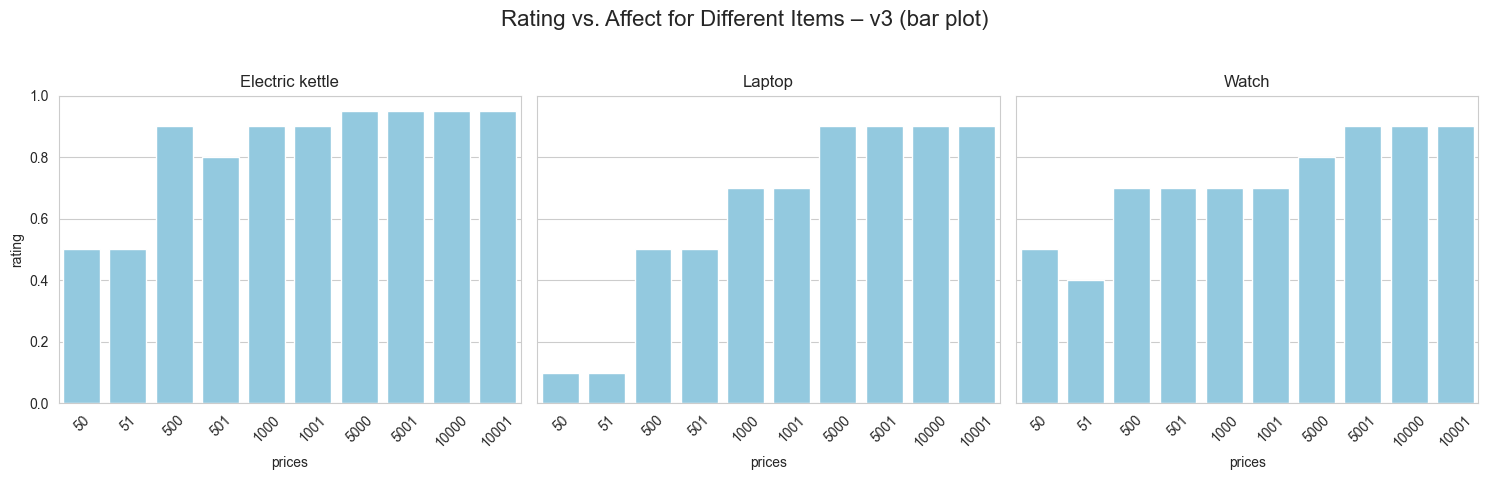

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the CSV file
file_path = 'experiment_3b_v3.csv'
data = pd.read_csv(file_path)

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Set a title for the entire plot
fig.suptitle('Rating vs. Affect for Different Items – v3 (bar plot)', fontsize=16)

# List of items
items = ['electric kettle', 'laptop', 'watch']

# Common color for the bars
bar_color = 'skyblue'

# Loop through the items and create a bar plot for each
for i, item in enumerate(items):
    # Filter the data for the current item
    item_data = data[data['item'] == item]
    
    # Create a bar plot with the same color for all bars
    sns.barplot(x='prices', y='rating', data=item_data, ax=axes[i], color=bar_color)
    
    # Set the title for each subplot
    axes[i].set_title(item.replace('_', ' ').capitalize())
    
    # Rotate the x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=45)

    # set y limit
    axes[i].set_ylim(0, 1.0)

# Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()


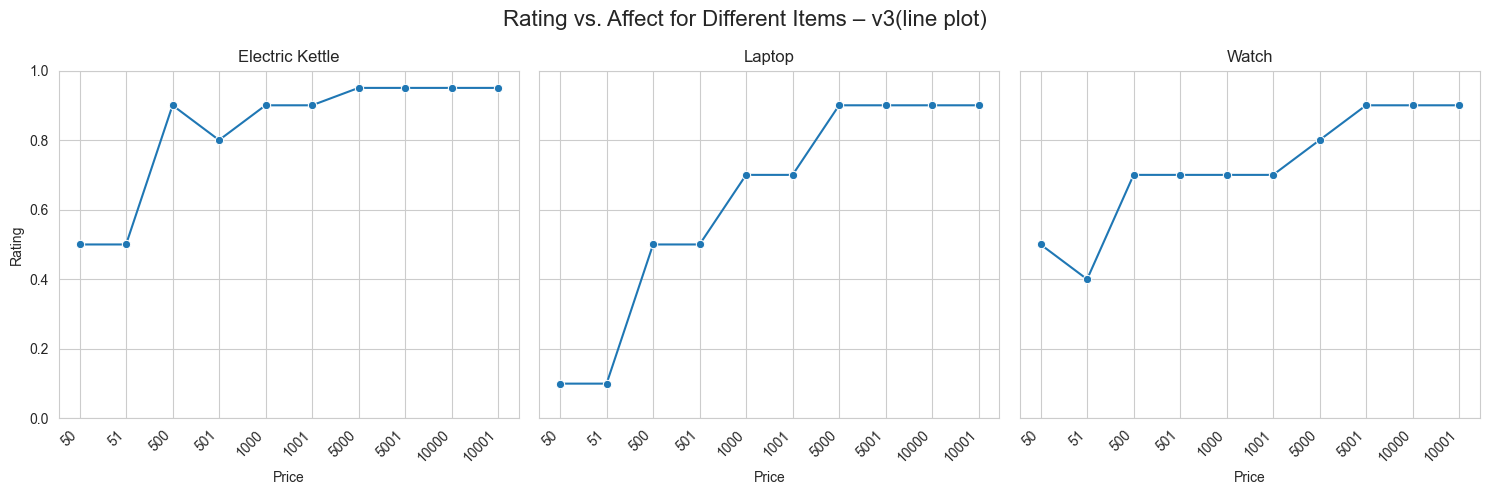

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = 'experiment_3b_v3.csv'
data = pd.read_csv(file_path)

# Convert prices to strings
data['prices'] = data['prices'].astype(str)

# Filter the data for each item
electric_kettle_data = data[data['item'] == 'electric kettle']
laptop_data = data[data['item'] == 'laptop']
watch_data = data[data['item'] == 'watch']

# Select the first 10 unique prices for each item
unique_prices_electric_kettle = electric_kettle_data['prices'].unique()[:10]
unique_prices_laptop = laptop_data['prices'].unique()[:10]
unique_prices_watch = watch_data['prices'].unique()[:10]

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create line plots connecting the points
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=True)

# Set a title for the entire plot
fig.suptitle('Rating vs. Affect for Different Items – v3 (line plot)', fontsize=16)

# Line plot for Electric Kettle
sns.lineplot(ax=axes[0], data=electric_kettle_data, x='prices', y='rating', marker='o')
axes[0].set_title('Electric Kettle')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Rating')
axes[0].set_xticks(unique_prices_electric_kettle)
axes[0].set_xticklabels(unique_prices_electric_kettle, rotation=45, ha='right')

# set y limit
axes[0].set_ylim(0, 1.0)

# Line plot for Laptop
sns.lineplot(ax=axes[1], data=laptop_data, x='prices', y='rating', marker='o')
axes[1].set_title('Laptop')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('')
axes[1].set_xticks(unique_prices_laptop)
axes[1].set_xticklabels(unique_prices_laptop, rotation=45, ha='right')

# set y limit
axes[1].set_ylim(0, 1.0)

# Line plot for Watch
sns.lineplot(ax=axes[2], data=watch_data, x='prices', y='rating', marker='o')
axes[2].set_title('Watch')
axes[2].set_xlabel('Price')
axes[2].set_ylabel('')
axes[2].set_xticks(unique_prices_watch)
axes[2].set_xticklabels(unique_prices_watch, rotation=45, ha='right')

# set y limit
axes[2].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


#### Plot for the scenario: "Sam bought a new electric kettle. A friend asked him,"Was it expensive?" Sam said,"It cost $50." The electric kettle was actually"

In [ ]:
import pandas as pd

# read in csv with name the column names
df = pd.read_csv("../experiment_1b_v1.csv", header=None, names=["scenarios"])

# add a column called "item" to the dataframe, repeat electric kettle, laptop, watch 10 times each
df["item"] = ["electric kettle"]*10 + ["laptop"]*10 + ["watch"]*10
# # from each line in the dataframe, extract the number (Sam bought a new watch. A friend asked him, ""Was it expensive?"" Sam said, ""It cost $50.")
df["utterance"] = df["scenarios"].str.extract(r"(\d+)", expand=False).astype(int)

# prices = [50, 51, 500, 501, 1000, 1001, 5000, 5001, 10000, 10001]

# df["utterance"] = prices*3

# convert the prices column to float
df["utterance"] = df["utterance"].astype(int)

# add experiment1b_new to the dataframe as the price
df["price"] = experiment1b_ratings_v1

# get the avergae price
df['avg_price'] = df.apply(lambda row: sum(row['price'])/len(row['price']), axis=1)

# save the dataframe
df.to_csv("df_experiment1b_v1.csv", index=False)

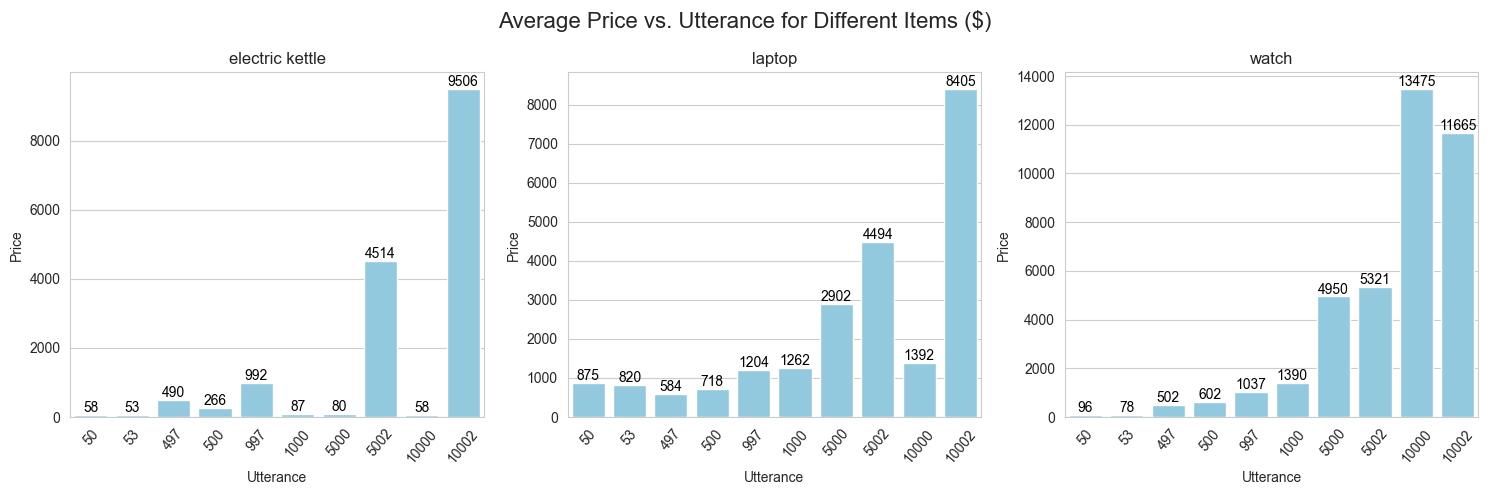

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'df_experiment1b_v1.csv'
data = pd.read_csv(file_path)
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Get the unique items in the dataset
unique_items = data['item'].unique()

# Function to add annotations on top of the bars
def annotate_bars(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

# Initialize a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=len(unique_items), figsize=(15, 5), sharex=False)

# Set a title for the entire plot
fig.suptitle('Average Price vs. Utterance for Different Items ($)', fontsize=16)

# Plot the relation between utterance and price for each item using bar plots with annotations
for ax, item in zip(axes, unique_items):
    subset = data[data['item'] == item]
    barplot = sns.barplot(x='utterance', y='avg_price', data=subset, ax=ax, color='skyblue')
    ax.set_title(item)
    ax.set_xlabel('Utterance')
    ax.set_ylabel('Price')
    ax.tick_params(axis='x', rotation=50)
    annotate_bars(ax)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# read in csv with name the column names
df = pd.read_csv("../experiment_1b_v1_dollar.csv", header=None, names=["scenarios"])

# add a column called "item" to the dataframe, repeat electric kettle, laptop, watch 10 times each
df["item"] = ["electric kettle"]*10 + ["laptop"]*10 + ["watch"]*10
# # from each line in the dataframe, extract the number (Sam bought a new watch. A friend asked him, ""Was it expensive?"" Sam said, ""It cost $50.")
df["utterance"] = df["scenarios"].str.extract(r"(\d+)", expand=False).astype(int)

# prices = [50, 51, 500, 501, 1000, 1001, 5000, 5001, 10000, 10001]

# df["utterance"] = prices*3

# convert the prices column to float
df["utterance"] = df["utterance"].astype(int)

# add experiment1b_new to the dataframe as the price
df["price"] = experiment1b_ratings_v1_dollar

# get the avergae price
df['avg_price'] = df.apply(lambda row: sum(row['price'])/len(row['price']), axis=1)

# save the dataframe
df.to_csv("df_experiment1b_v1_dollar.csv", index=False)

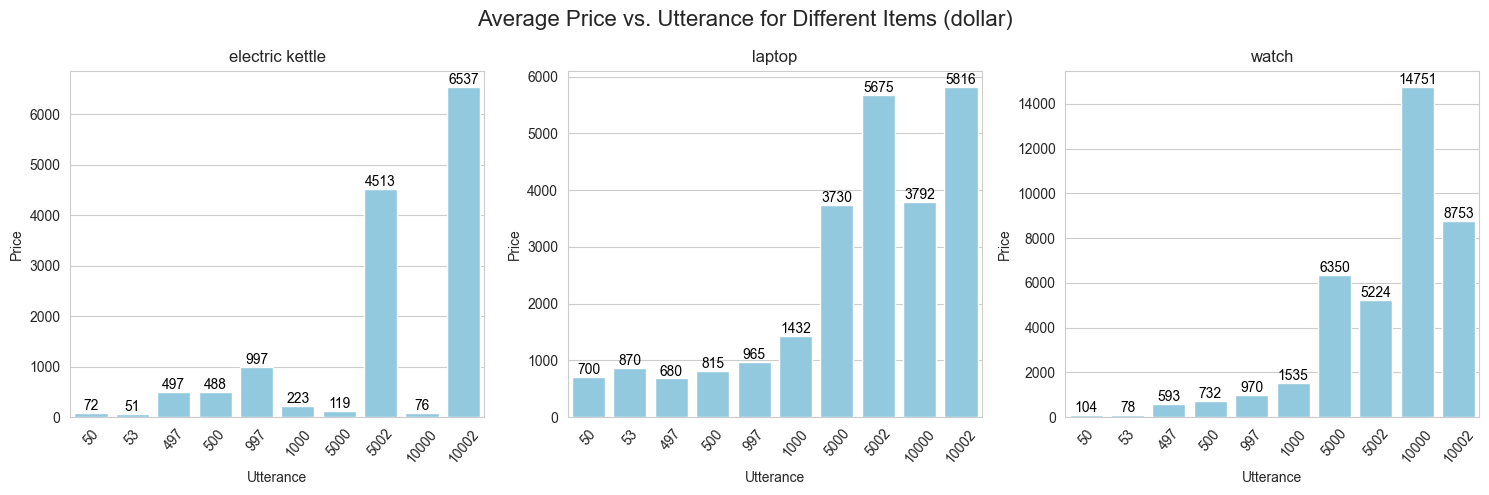

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'df_experiment1b_v1_dollar.csv'
data = pd.read_csv(file_path)
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Get the unique items in the dataset
unique_items = data['item'].unique()

# Function to add annotations on top of the bars
def annotate_bars(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

# Initialize a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=len(unique_items), figsize=(15, 5), sharex=False)

# Set a title for the entire plot
fig.suptitle('Average Price vs. Utterance for Different Items (dollar)', fontsize=16)

# Plot the relation between utterance and price for each item using bar plots with annotations
for ax, item in zip(axes, unique_items):
    subset = data[data['item'] == item]
    barplot = sns.barplot(x='utterance', y='avg_price', data=subset, ax=ax, color='skyblue')
    ax.set_title(item)
    ax.set_xlabel('Utterance')
    ax.set_ylabel('Price')
    ax.tick_params(axis='x', rotation=50)
    annotate_bars(ax)

plt.tight_layout()
plt.show()


#### Price Prior human

In [19]:
experiment3a_human = pd.read_csv('experiment3a-normalized.csv')

experiment3a_human

# remove workerID, order, stateType, and stateRounded
experiment3a_human = experiment3a_human.drop(columns=['workerID', 'order', 'stateType', 'stateRounded'])

# group by domain then by state and then get the mean of stateProb
experiment3a_human = experiment3a_human.groupby(['domain', 'state']).mean().reset_index()

# save the dataframe
experiment3a_human.to_csv("experiment3a-human.csv", index=False)

#### Affect Prior human 

In [518]:
experiment3b_human = pd.read_csv('experiment3b-raw.csv')

experiment3b_human = experiment3b_human.drop(columns=['workerID', 'order',])

# if stateType is sharp, resign the stateRounded number plus one in the same row
experiment3b_human.loc[experiment3b_human['stateType'] == 'sharp', 'stateRounded'] = experiment3b_human['stateRounded'] + 1

# remove the stateType column
experiment3b_human = experiment3b_human.drop(columns=['stateType'])

# rename the stateRounded column to state
experiment3b_human = experiment3b_human.rename(columns={"stateRounded": "state"})

# groupby domain then by state the get the mean of affectProb
experiment3b_human = experiment3b_human.groupby(['domain', 'state']).mean().reset_index()

# save the dataframe
experiment3b_human.to_csv("experiment3b-human.csv", index=False)


#### Correlation Plot (Fig 2a)

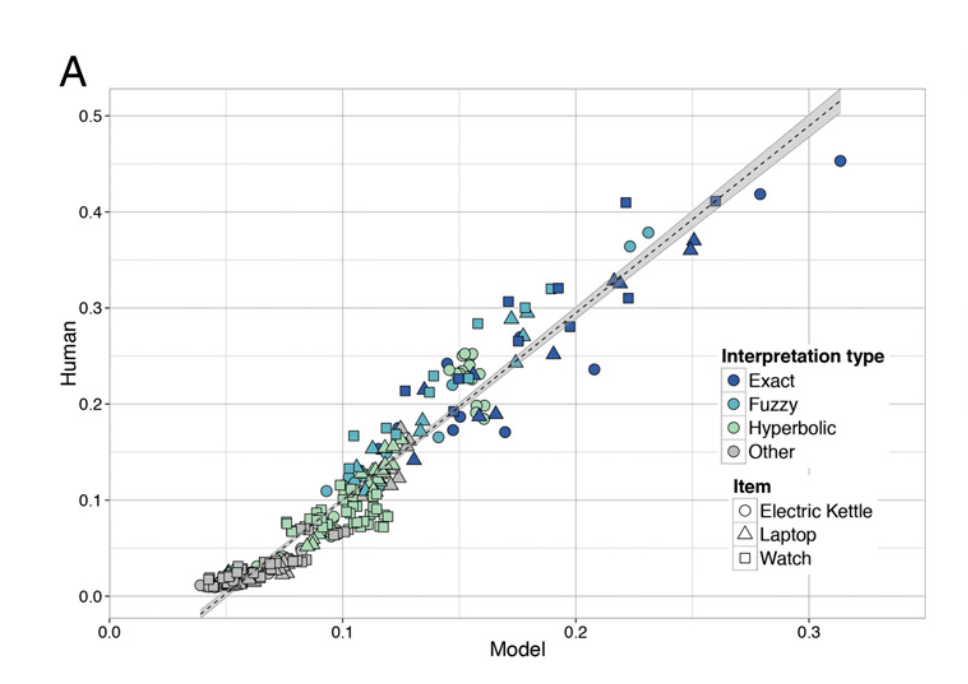

In [390]:
correlation_human = pd.read_csv("experiment1-normalized.csv")

# remove the columns: workerID, order
correlation_human = correlation_human.drop(columns=['workerID', 'order'])

# add one column called interpretationType. For each row, if state == utterance, assign value "Exact"; if abs(utterance-state) == 1, assign value "Fuzzy"; if utterance / state >= 10, assign value "Hyerbolic"; others assigns value "Other"
correlation_human['interpretationType'] = correlation_human.apply(lambda row: 'Exact' if row['state'] == row['utterance'] else ('Fuzzy' if abs(row['state'] - row['utterance']) == 1 else ('Hyperbolic' if row['utterance'] / row['state'] >= 2 else 'Other')), axis=1) 

# remove columns: utterance, utteranceType, utteranceRounded, stateType, stateRounded
correlation_human = correlation_human.drop(columns=['utteranceExact', 'utteranceType', 'utteranceRounded', 'stateType', 'stateRounded', 'affectProb'])

Each point represents an utterance and price state pair (u, s). 

The x coordinate of each point is the probability of the model interpreting utterance u as meaning price state s;

In [395]:
# groupby domain, the by interpretationType, then by utterance, then by state, and get the mean of stateProb
correlation_human = correlation_human.groupby(['domain', 'interpretationType', 'utterance', 'state']).mean().reset_index()

# save the dataframe
correlation_human.to_csv("correlation_human.csv", index=False)

##### code for figure 5B

In [ ]:
df_5b_v2 = pd.read_csv("../experiment_1b_v2.csv", header=None, names=["scenarios"])

# add a column called domain with the first 100 rows as electric kettle, the second 100 rows as laptop, the third 100 rows as watch
df_5b_v2["domain"] = ["electric kettle"]*100 + ["laptop"]*100 + ["watch"]*100

# extract the two numbers from each line of the scenarios column and let the two to be in a list
df_5b_v2['numbers'] = df_5b_v2['scenarios'].str.findall(r'\d+')

# the first number in the numbers column should be in the new column called price, the second number should be in the new column called utterance
df_5b_v2['utterance'] = df_5b_v2['numbers'].str[0]
df_5b_v2['state'] = df_5b_v2['numbers'].str[-1]

# drop the numbers column
df_5b_v2 = df_5b_v2.drop(columns=['numbers'])

# drop the column called scenarios
df_5b_v2 = df_5b_v2.drop(columns=['scenarios'])

# add experiment1b_ratings_v2 list to the dataframe as the rating
df_5b_v2["stateProb"] = experiment1b_ratings_v2

# datatype of state and utterance should be int
df_5b_v2['state'] = df_5b_v2['state'].astype(int)
df_5b_v2['utterance'] = df_5b_v2['utterance'].astype(int)

# datatype of rating should be float
df_5b_v2['stateProb'] = df_5b_v2['stateProb'].astype(float)

# add a column called stateType, if state % 10 == 0, assign value "round", else assign value "sharp"
df_5b_v2['stateType'] = df_5b_v2.apply(lambda row: 'round' if row['state'] % 10 == 0 else 'sharp', axis=1)

# add a column called utteranceType, if utterance % 10 == 0, assign value "round", else assign value "sharp"
df_5b_v2['utteranceType'] = df_5b_v2.apply(lambda row: 'round' if row['utterance'] % 10 == 0 else 'sharp', axis=1)

# # if stateType == "sharp", then reassign the state value to the closest round number and then plus 1
df_5b_v2.loc[df_5b_v2['stateType'] == 'sharp', 'state'] = df_5b_v2['state'].apply(lambda x: round(x, -1)) + 1

# if utteranceType == "sharp", then reassign the utterance value to the closest round number and then plus 1
df_5b_v2.loc[df_5b_v2['utteranceType'] == 'sharp', 'utterance'] = df_5b_v2['utterance'].apply(lambda x: round(x, -1)) + 1

# drop the columns: stateType, utteranceType
df_5b_v2 = df_5b_v2.drop(columns=['stateType', 'utteranceType'])

# rename the columns to item, utterance, prices, rating
df_5b_v2 = df_5b_v2.rename(columns={"domain": "item", "utterance": "utterance", "state": "prices", "stateProb": "rating"})

# save the dataframe to a csv file
df_5b_v2.to_csv('experiment_1b_v2.csv', index=False)